## Hipótesis previas

Antes de explorar los datos, planteamos las siguientes hipótesis sobre qué variables pueden influir en si una persona gana más o menos de 50.000 u.m.:

1. **Hipótesis de Género**: Los hombres tendrán una mayor probabilidad de superar los 50.000 u.m. debido a las brechas salariales históricas por género.

2. **Hipótesis de Educación**: Las personas con mayor nivel educativo tendrán salarios más altos. Títulos universitarios o de posgrado estarán asociados a ingresos >50K.

3. **Hipótesis de Edad**: Las personas de mayor edad tendrán más experiencia laboral acumulada y, por tanto, mayores ingresos, hasta llegar a un punto de inflexión (jubilación).

4. **Hipótesis de Estado Civil**: Las personas casadas (especialmente Married-civ-spouse) tendrán mayores ingresos, posiblemente por el efecto de selección (parejas con mayor estabilidad económica).

5. **Hipótesis de Ocupación**: Las ocupaciones ejecutivas y profesionales especializadas (Exec-managerial, Prof-specialty) estarán más asociadas a ingresos altos.

6. **Hipótesis de Horas trabajadas**: Las personas que trabajan más horas semanales tendrán más probabilidad de superar los 50.000 u.m.

7. **Hipótesis de Capital**: Las personas con ganancias de capital (capital-gain > 0) tendrán ingresos más altos, ya que estas ganancias suelen estar asociadas a inversiones y patrimonio.

8. **Hipótesis de Tipo de empleador**: Los trabajadores del gobierno federal y los autónomos con empresa (Self-emp-inc) tendrán salarios más altos en comparación con los empleados privados.

9. **Hipótesis de País de origen**: La mayoría de registros serán de Estados Unidos. Podría existir diferencia entre nativos y no nativos.

10. **Hipótesis de Interacciones**:
    - **Género y Educación**: Las mujeres con educación universitaria reducirán la brecha salarial respecto a los hombres.
    - **Edad y Ocupación**: Las personas mayores en ocupaciones ejecutivas concentrarán la mayoría de los ingresos altos.
    - **Estado Civil y Género**: Los hombres casados serán el grupo con mayor proporción de ingresos >50K.

# Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway
import warnings
from sklearn.feature_selection import mutual_info_classif,mutual_info_classif
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df_raw = pd.read_csv('../data/income_data.csv')

In [4]:
df_raw.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df_raw.shape

(48842, 15)

In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [7]:
df_raw['educational-num']=df_raw['educational-num'].astype('object')

In [8]:
# 1. Forzamos que 'Male' sea 0 y 'Female' sea 1
df_raw['gender_codificada'] = df_raw['gender'].map({'Male': 0, 'Female': 1})

# 2. Hacemos lo mismo con 'income': 0 para <=50K y 1 para >50K
df_raw['income_codificada'] = df_raw['income'].map({'<=50K': 0, '>50K': 1})

In [9]:
numeric_cols = df_raw.select_dtypes(exclude='object').columns.to_list()
str_cols = df_raw.select_dtypes(include='object').columns.to_list()

print(f'variables numericas {numeric_cols}')
print(f'-----------------------------------------------')
print(f'variables categoricas {str_cols}')

variables numericas ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'gender_codificada', 'income_codificada']
-----------------------------------------------
variables categoricas ['workclass', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


Vemos como se distribuye la variable objetivo

In [10]:
df_raw['income'].value_counts(normalize=True)*100

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

Observamos que no hay valores nulos

In [11]:
df_raw.isnull().sum()

age                  0
workclass            0
fnlwgt               0
education            0
educational-num      0
marital-status       0
occupation           0
relationship         0
race                 0
gender               0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country       0
income               0
gender_codificada    0
income_codificada    0
dtype: int64

Observamos si el df_raw tiene duplicados los vamos a eliminar ya que generan ruido para el modelo.

In [12]:
total_duplicados = df_raw.duplicated().sum()
print(f"Total de registros completamente duplicados: {total_duplicados}")

if total_duplicados > 0:
    print("\nMuestra de registros duplicados:")
    # keep=False nos muestra todas las copias del registro repetido
    print(df_raw[df_raw.duplicated(keep=False)].sort_values(by=list(df_raw.columns)[:3]).head(10))
else:
    print("\n¡Limpio! No hay filas repetidas.")

Total de registros completamente duplicados: 52

Muestra de registros duplicados:
       age     workclass  fnlwgt     education educational-num marital-status  \
4152    17       Private  153021          12th               8  Never-married   
40948   17       Private  153021          12th               8  Never-married   
3900    18  Self-emp-inc  378036          12th               8  Never-married   
15960   18  Self-emp-inc  378036          12th               8  Never-married   
8116    19             ?  167428  Some-college              10  Never-married   
26375   19             ?  167428  Some-college              10  Never-married   
33954   19       Private   97261       HS-grad               9  Never-married   
34979   19       Private   97261       HS-grad               9  Never-married   
1668    19       Private  130431       5th-6th               3  Never-married   
19399   19       Private  130431       5th-6th               3  Never-married   

            occupation   r

In [13]:
df_raw = df_raw.drop_duplicates()

## Análisis Univariado

###  Columnas numéricas

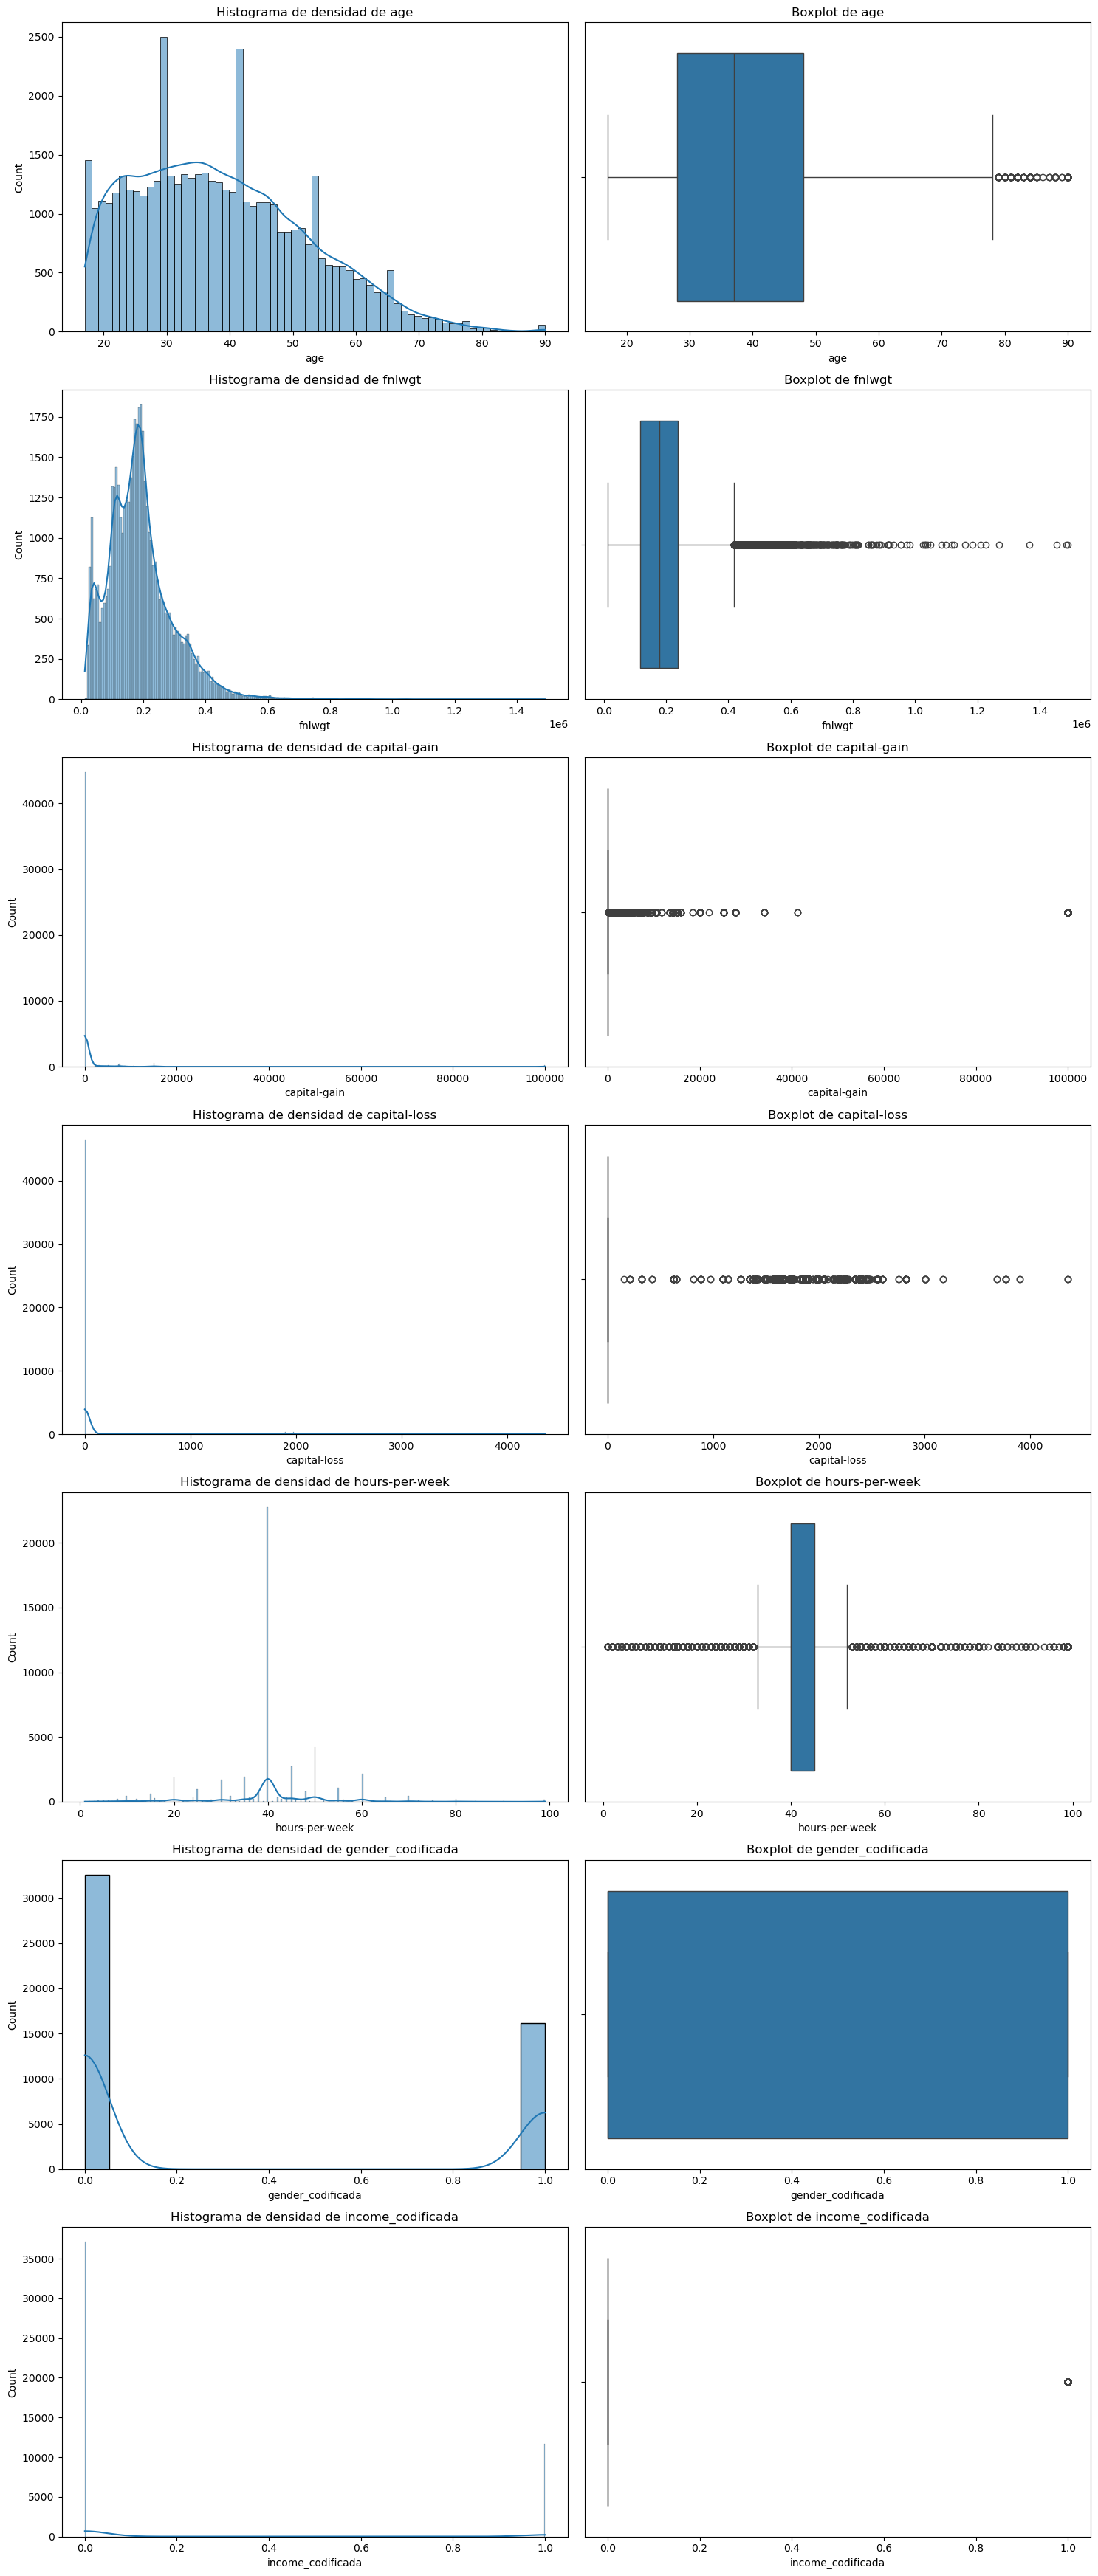

In [14]:
fig, axes = plt.subplots(nrows=len(df_raw.select_dtypes(include=[np.number]).columns), ncols=2, figsize=(15, 5 * len(df_raw.select_dtypes(include=[np.number]).columns)))

for i, column in enumerate(df_raw[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df_raw[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_raw[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

In [15]:
#Calcular asimetría
"""
valor > 0 -> distribución asimétrica a la derecha
valor = 0 -> distribución simétrica
valor < 0 -> distribución asimétrica a la izquierda
"""
df_raw[numeric_cols].skew()

age                   0.556582
fnlwgt                1.439698
capital-gain         11.888265
capital-loss          4.567037
hours-per-week        0.239652
gender_codificada     0.715690
income_codificada     1.221366
dtype: float64

En cuanto a la asimetría, las variables capital-gain y capital-loss presentan una asimetría positiva extremadamente elevada, lo que indica que la inmensa mayoría de individuos tiene valor 0 en ambas variables y solo unos pocos registros concentran valores muy altos. La variable fnlwgt también muestra una asimetría positiva notable, reflejando la presencia de outliers en los pesos censales. Por su parte, age y hours-per-week presentan una asimetría positiva moderada, con distribuciones relativamente centradas pero con una cola derecha más pronunciada. La variable educational-num es la más simétrica del conjunto.


In [16]:
#Calcular la curtosis
"""
valor > 0 -> distribución leptocúrtica
valor = 0 -> distribución mesocúrtica
valor < 0 -> distribución platicúrtica
"""
df_raw[numeric_cols].kurt()

age                   -0.186851
fnlwgt                 6.061237
capital-gain         152.526968
capital-loss          19.987928
hours-per-week         2.950820
gender_codificada     -1.487849
income_codificada     -0.508285
dtype: float64

En cuanto a la curtosis, capital-gain y capital-loss presentan valores leptocúrticos extremadamente altos, lo que confirma la presencia de colas muy pesadas y outliers pronunciados, es decir, una concentración masiva de valores en cero con unos pocos casos atípicos de gran magnitud. El resto de variables numéricas (age, hours-per-week, educational-num y fnlwgt) muestran curtosis más moderadas, aunque fnlwgt también tiende a un comportamiento leptocúrtico por la dispersión de sus pesos censales.

In [17]:
df_raw[numeric_cols].describe(percentiles=[.25, .50, .75, .90, .95, .99])

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,gender_codificada,income_codificada
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,1080.217688,87.595573,40.425886,0.331543,0.239414
std,13.708493,1.056172e+05,7455.905921,403.209129,12.392729,0.470773,0.426730
min,17.000000,1.228500e+04,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,1.175550e+05,0.000000,0.000000,40.000000,0.000000,0.000000
50%,37.000000,1.781385e+05,0.000000,0.000000,40.000000,0.000000,0.000000
75%,48.000000,2.376062e+05,0.000000,0.000000,45.000000,1.000000,0.000000
90%,58.000000,3.284660e+05,0.000000,0.000000,55.000000,1.000000,1.000000
95%,63.000000,3.795220e+05,5013.000000,0.000000,60.000000,1.000000,1.000000
99%,74.000000,5.095142e+05,15024.000000,2001.000000,80.000000,1.000000,1.000000


In [18]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)]
    perc = (len(outliers) / len(df_raw)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
age: 215 registros (0.44%)
fnlwgt: 1453 registros (2.98%)
capital-gain: 4035 registros (8.27%)
capital-loss: 2282 registros (4.68%)
hours-per-week: 13486 registros (27.64%)
gender_codificada: 0 registros (0.00%)
income_codificada: 11681 registros (23.94%)


Podemos ver que la variable 'capital_loss' tiene muchos valores = 0, vamos a ver su distribución filtrando los 0

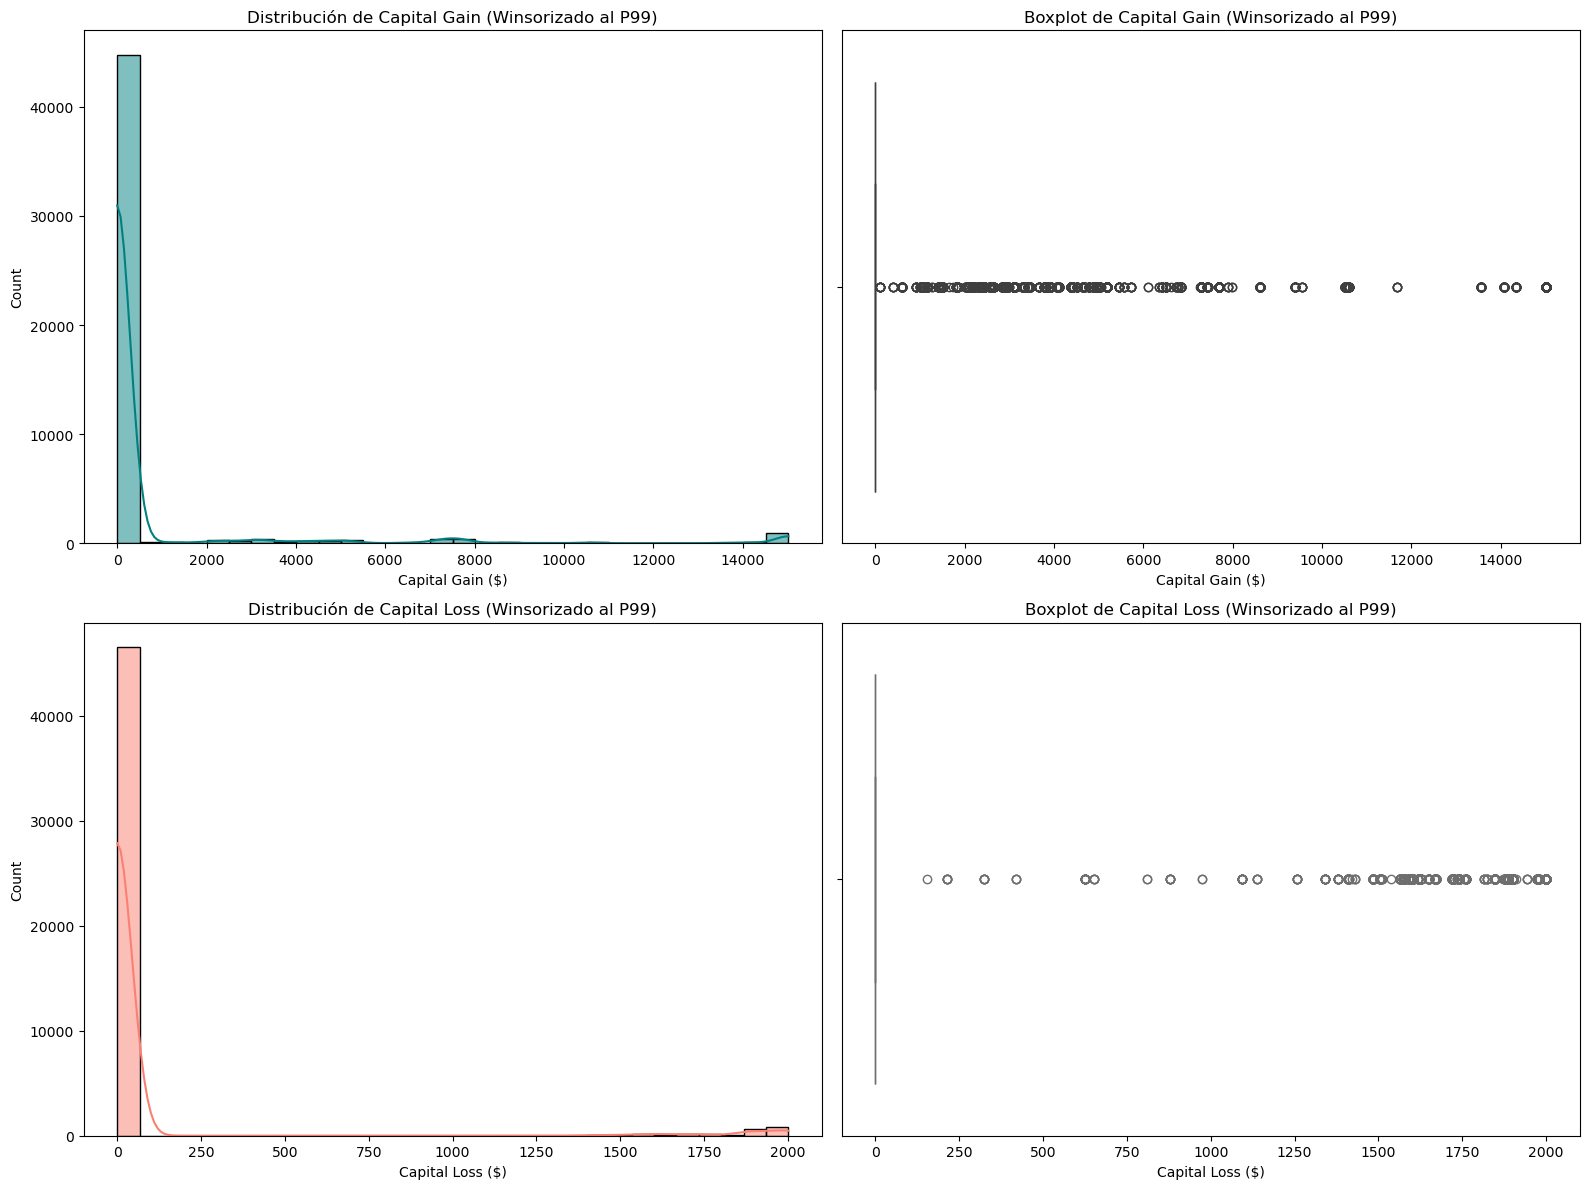

In [19]:
# 1. Calculamos los percentiles 99
upper_gain = df_raw['capital-gain'].quantile(0.99)
upper_loss = df_raw['capital-loss'].quantile(0.99)

# 2. Aplicamos la winsorización en nuevas columnas
df_raw['capital-gain-winsorized'] = df_raw['capital-gain'].clip(upper=upper_gain)
df_raw['capital-loss-winsorized'] = df_raw['capital-loss'].clip(upper=upper_loss)

# 3. Creamos una cuadrícula de 2x2 para las gráficas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Fila 1: Capital Gain Winsorized
sns.histplot(df_raw['capital-gain-winsorized'], kde=True, ax=axes[0, 0], color='teal', bins=30)
axes[0, 0].set_title('Distribución de Capital Gain (Winsorizado al P99)')
axes[0, 0].set_xlabel('Capital Gain ($)')

sns.boxplot(x=df_raw['capital-gain-winsorized'], ax=axes[0, 1], color='lightseagreen')
axes[0, 1].set_title('Boxplot de Capital Gain (Winsorizado al P99)')
axes[0, 1].set_xlabel('Capital Gain ($)')

# Fila 2: Capital Loss Winsorized
sns.histplot(df_raw['capital-loss-winsorized'], kde=True, ax=axes[1, 0], color='salmon', bins=30)
axes[1, 0].set_title('Distribución de Capital Loss (Winsorizado al P99)')
axes[1, 0].set_xlabel('Capital Loss ($)')

sns.boxplot(x=df_raw['capital-loss-winsorized'], ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Boxplot de Capital Loss (Winsorizado al P99)')
axes[1, 1].set_xlabel('Capital Loss ($)')

plt.tight_layout()
plt.show()

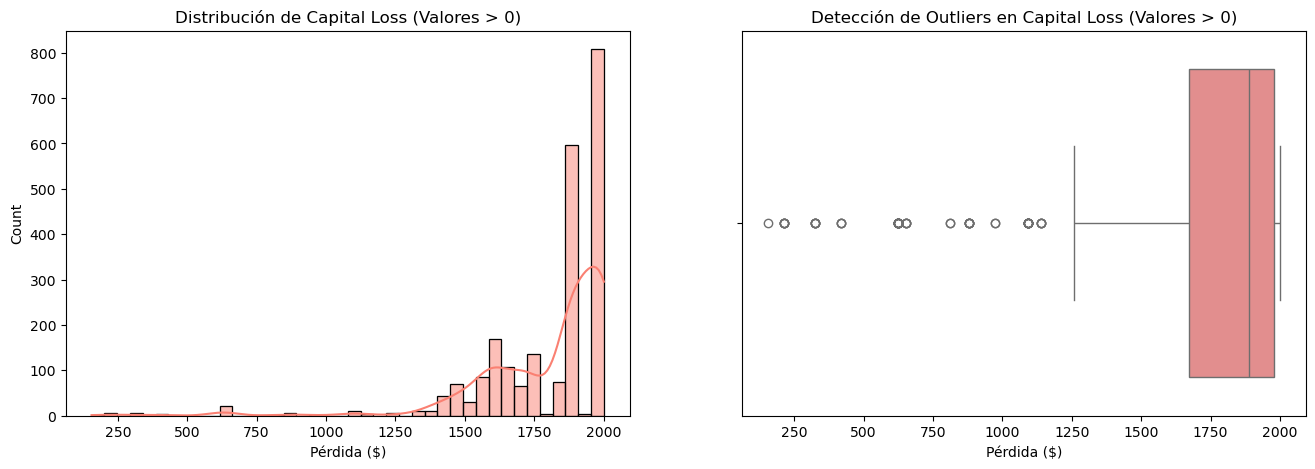

Registros con pérdida = 0: 46508 (95.32%)
Valor máximo de pérdida: 2001


In [20]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
# (Asegúrate de que el nombre coincida exactamente con cómo creaste la columna en la celda anterior)
loss_nonzero = df_raw[df_raw['capital-loss-winsorized'] > 0]['capital-loss-winsorized']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital Loss (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot corregido: ahora también usa 'loss_nonzero' para no mostrar el colapso en 0
sns.boxplot(x=loss_nonzero, ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital Loss (Valores > 0)')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés (Corregido el nombre de la columna aquí también)
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-loss-winsorized'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-loss-winsorized'].max()}")

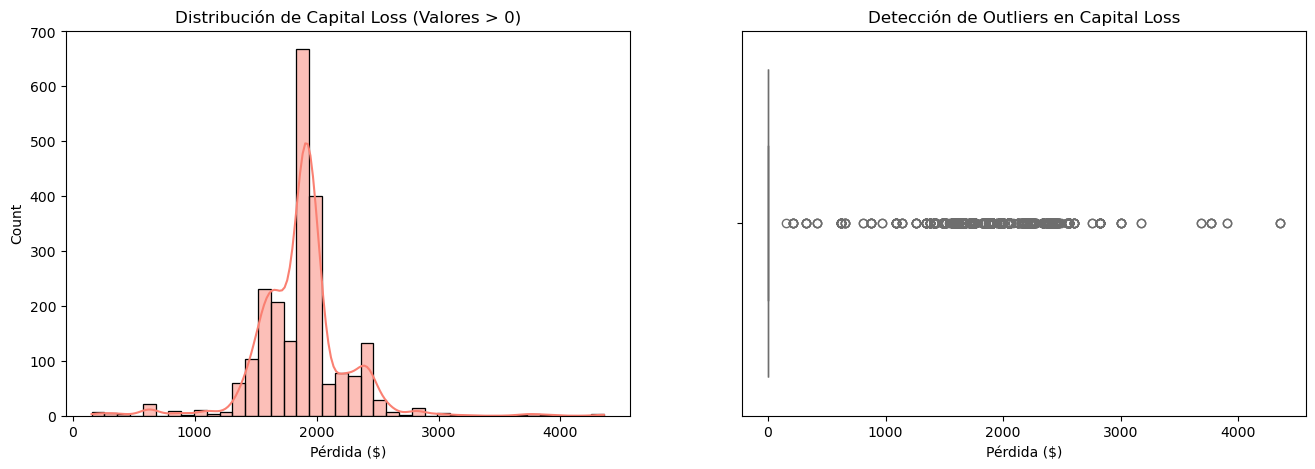

Registros con pérdida = 0: 46508 (95.32%)
Valor máximo de pérdida: 4356


In [21]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
loss_nonzero = df_raw[df_raw['capital-loss'] > 0]['capital-loss']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital Loss (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot para detectar valores extremos
sns.boxplot(x=df_raw['capital-loss'], ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital Loss')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-loss'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-loss'].max()}")

Podemos ver que la distribución se ve mucho mas clara, pero los registros = 0 representan un 95.33% de todos los valores de la variable, por lo cual eliminarlos posiblemente distorsione la variable. Tenemos prácticamente el mismo caso con la variable 'Capital_gain'

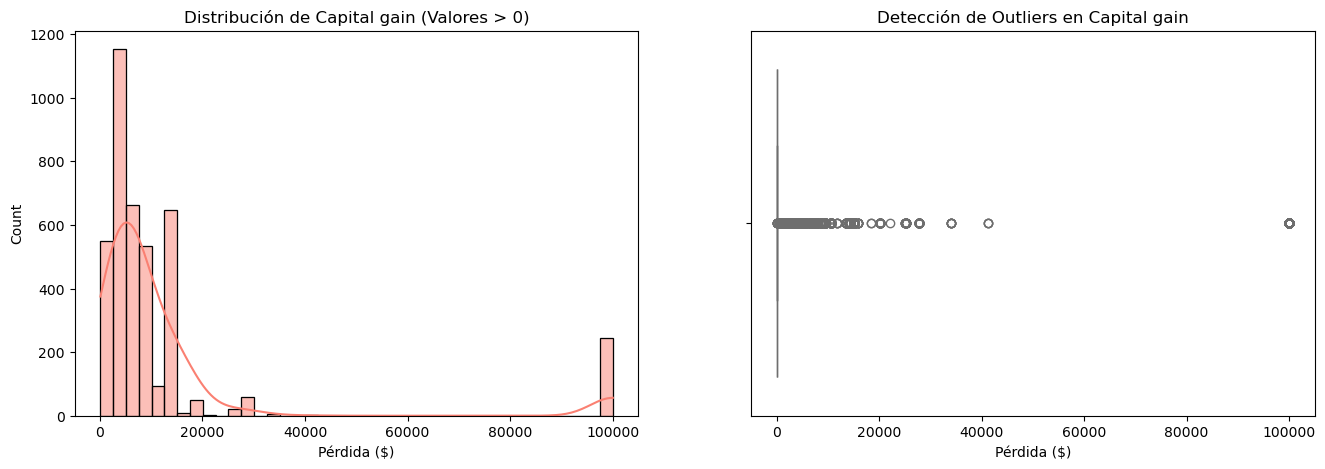

Registros con pérdida = 0: 44755 (91.73%)
Valor máximo de pérdida: 99999


In [22]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
loss_nonzero = df_raw[df_raw['capital-gain'] > 0]['capital-gain']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital gain (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot para detectar valores extremos
sns.boxplot(x=df_raw['capital-gain'], ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital gain')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-gain'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-gain'].max()}")

 Hemos probado la winsorización, pero no hemos visto que pueda ser útil en los casos de estas columnas. Tenemos en mente dos opciones, crear dos columnas binarias que indiquen si hubo ganancias o pérdidas, o simplemente no tratar las variables y confiar en la robustes de los modelos.

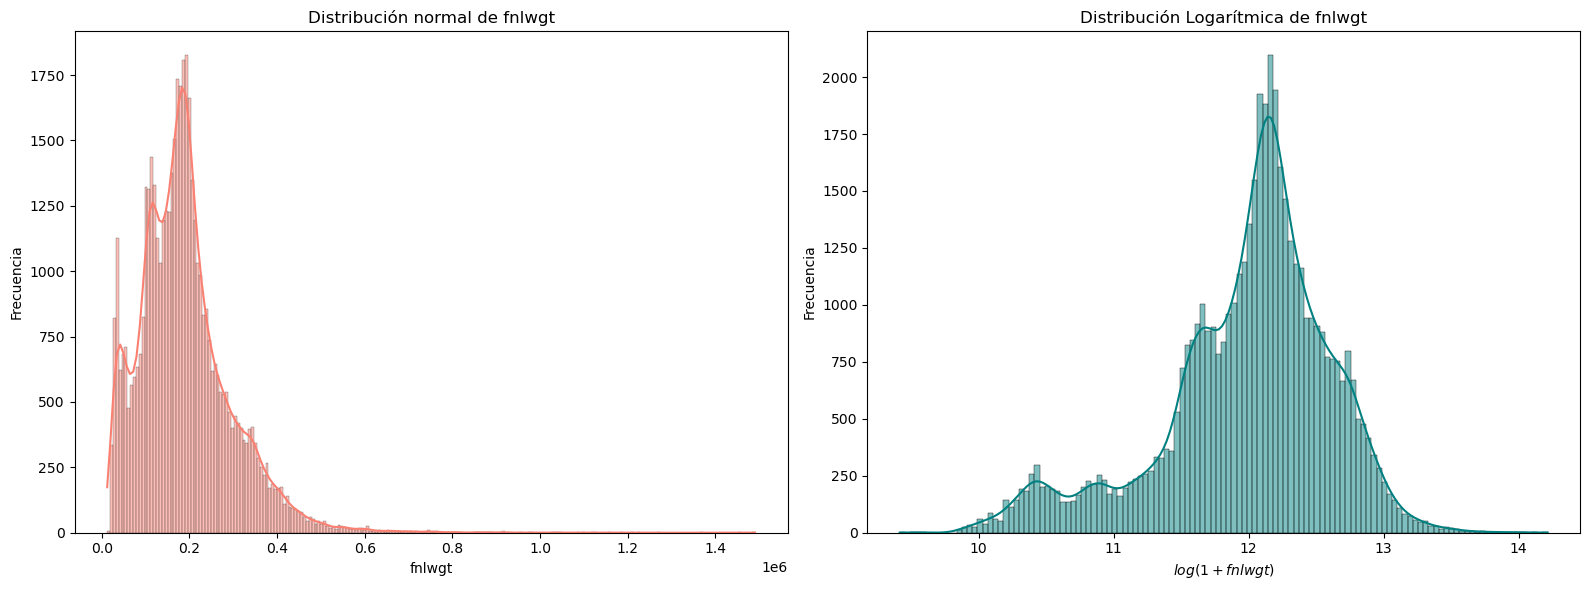

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico origianal 'fnlwgt'
sns.histplot(df_raw['fnlwgt'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribución normal de fnlwgt')
axes[0].set_xlabel('fnlwgt')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfico para 'fnlwgt' usando log(1+x)
sns.histplot(np.log1p(df_raw['fnlwgt']), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribución Logarítmica de fnlwgt')
axes[1].set_xlabel('$log(1 + fnlwgt)$')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Observamos que en la distribución normal presenta skewness y una cúrtosis alta. Por lo que para reducir el impacto de los outliers vamos a intentar reducirlo por un logaritmo. El resultado de la derecha es una distribución logarítima de 'fnlwgt', observamos que hemos tomado la decisión correcta para poder ver la distribución de manera mucho más clara. Por lo que en el preprocessing, vamos a implementar el logaritmo a esta variable.

#### Hours-per-week

Vamos a aplicar una escala logaritmica en 'hours-per-week' para ver si mejora su distribución

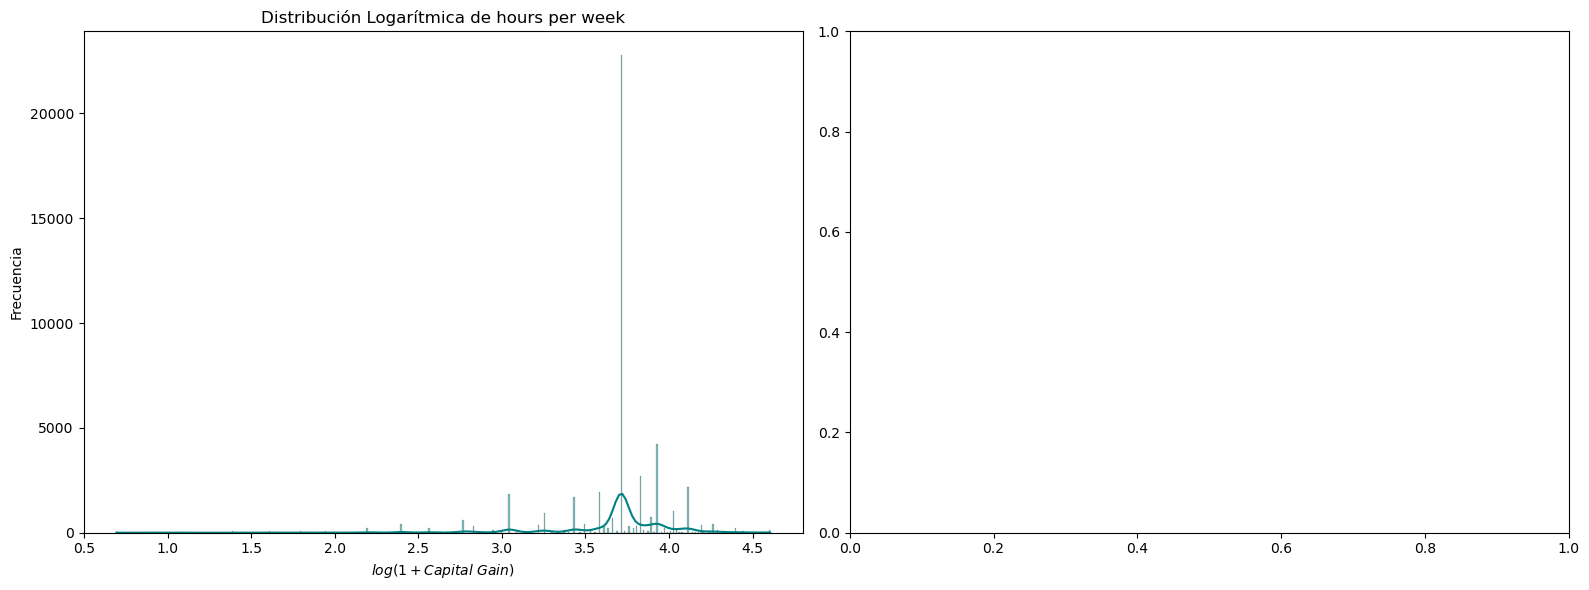

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(np.log1p(df_raw['hours-per-week']), kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución Logarítmica de hours per week')
axes[0].set_xlabel('$log(1 + Capital\ Gain)$')
axes[0].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Filtramos quitando el 1% más bajo y el 1% más alto

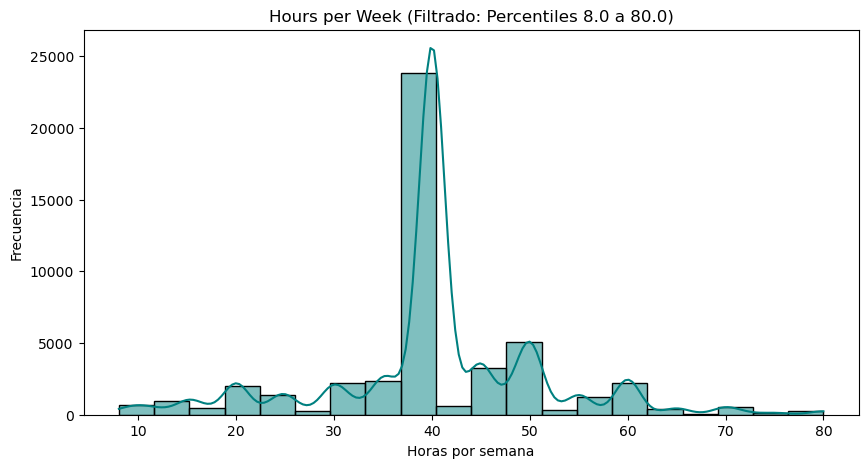

Original: 48790 filas
Filtrado: 48017 filas


In [25]:
# 1. Calculamos los límites (Percentil 1 y Percentil 99)
lower_limit = df_raw['hours-per-week'].quantile(0.01)
upper_limit = df_raw['hours-per-week'].quantile(0.99)

# 2. Filtramos el DataFrame
df_filtered = df_raw[(df_raw['hours-per-week'] >= lower_limit) & (df_raw['hours-per-week'] <= upper_limit)]

# 3. Visualizamos
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['hours-per-week'], kde=True, color='teal', bins=20)

plt.title(f'Hours per Week (Filtrado: Percentiles {lower_limit} a {upper_limit})')
plt.xlabel('Horas por semana')
plt.ylabel('Frecuencia')
plt.show()

print(f"Original: {len(df_raw)} filas")
print(f"Filtrado: {len(df_filtered)} filas")

Podemos observar que la distribución es considerablemente mas visible.

In [26]:
# 1. Calculamos los percentiles 1 y 99 para hours-per-week
lower_hours = df_raw['hours-per-week'].quantile(0.01)
upper_hours = df_raw['hours-per-week'].quantile(0.99)

print(f"Límite inferior para el recorte (P1): {lower_hours} horas")
print(f"Límite superior para el recorte (P99): {upper_hours} horas\n")

# 2. Aplicamos la winsorización simétrica usando .clip()
# Guardamos el resultado en una nueva columna para mantener la original intacta
df_raw['hours-per-week-winsorized'] = df_raw['hours-per-week'].clip(lower=lower_hours, upper=upper_hours)

# 3. Comparamos los estadísticos antes y después para verificar el cambio
print("Comparativa de la transformación:")
print(df_raw[['hours-per-week', 'hours-per-week-winsorized']].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

Límite inferior para el recorte (P1): 8.0 horas
Límite superior para el recorte (P99): 80.0 horas

Comparativa de la transformación:
       hours-per-week  hours-per-week-winsorized
count    48790.000000               48790.000000
mean        40.425886                  40.377065
std         12.392729                  11.973274
min          1.000000                   8.000000
1%           8.000000                   8.000000
5%          18.000000                  18.000000
25%         40.000000                  40.000000
50%         40.000000                  40.000000
75%         45.000000                  45.000000
95%         60.000000                  60.000000
99%         80.000000                  80.000000
max         99.000000                  80.000000


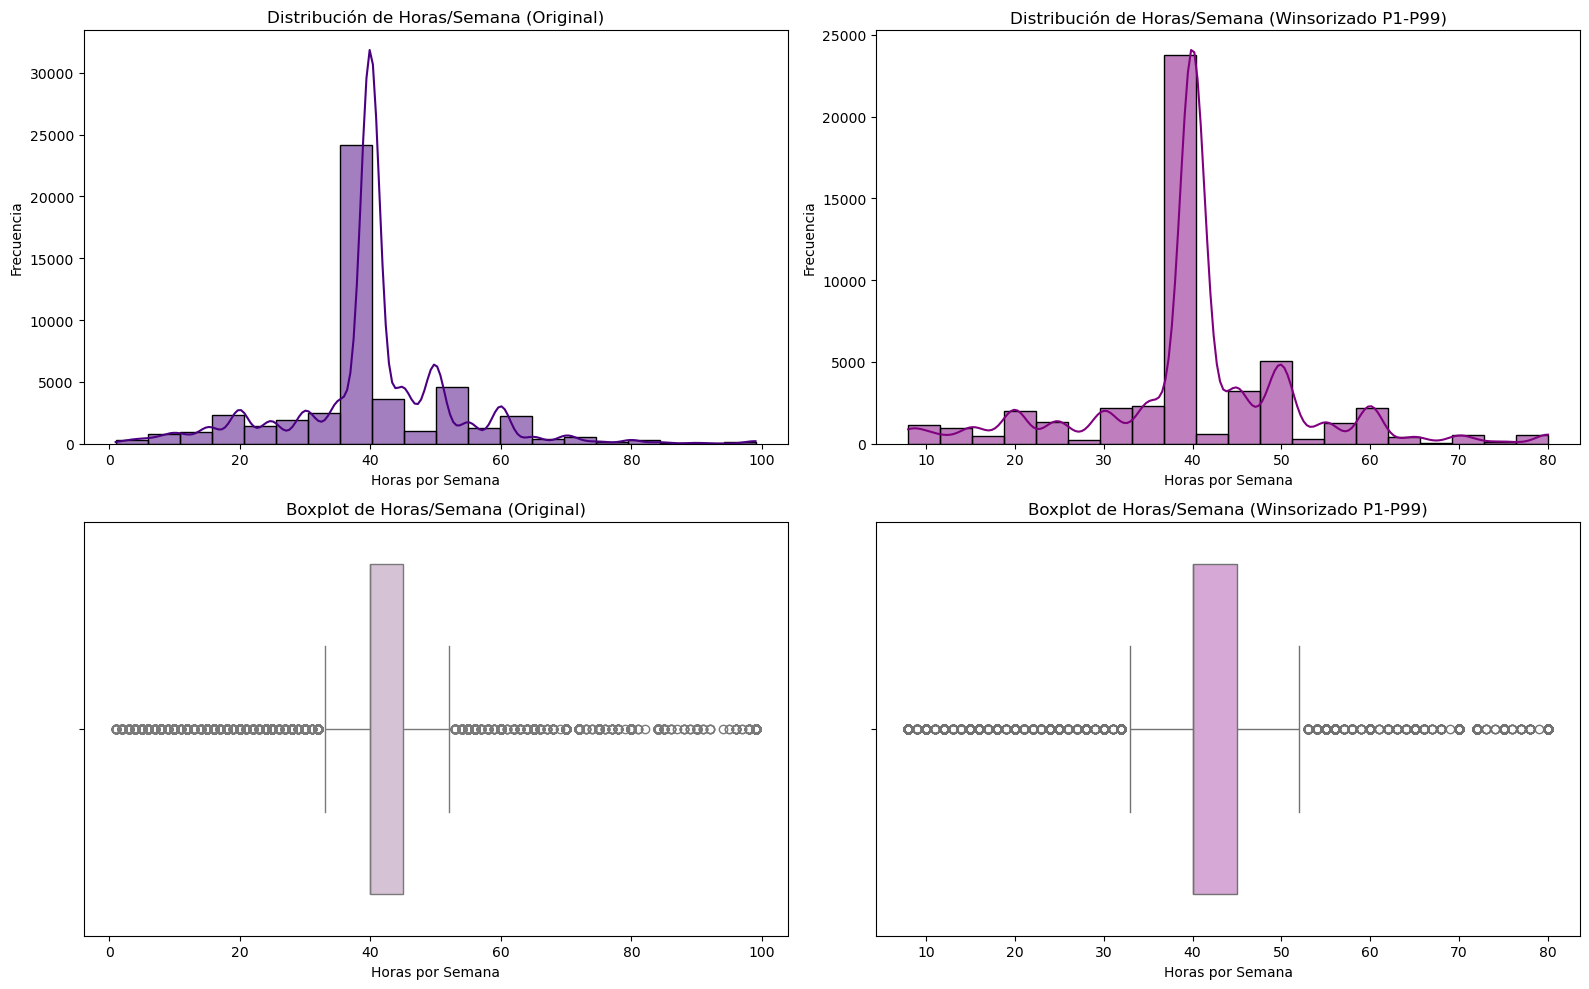

In [27]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1, ax2, ax3, ax4 = axes.flatten()


sns.histplot(df_raw['hours-per-week'], kde=True, ax=ax1, color='indigo', bins=20)
ax1.set_title('Distribución de Horas/Semana (Original)')
ax1.set_xlabel('Horas por Semana')
ax1.set_ylabel('Frecuencia')

sns.histplot(df_raw['hours-per-week-winsorized'], kde=True, ax=ax2, color='purple', bins=20)
ax2.set_title('Distribución de Horas/Semana (Winsorizado P1-P99)')
ax2.set_xlabel('Horas por Semana')
ax2.set_ylabel('Frecuencia')



sns.boxplot(x=df_raw['hours-per-week'], ax=ax3, color='thistle')
ax3.set_title('Boxplot de Horas/Semana (Original)')
ax3.set_xlabel('Horas por Semana')


sns.boxplot(x=df_raw['hours-per-week-winsorized'], ax=ax4, color='plum')
ax4.set_title('Boxplot de Horas/Semana (Winsorizado P1-P99)')
ax4.set_xlabel('Horas por Semana')

plt.tight_layout()
plt.show()

### Age

Vemos que la columna 'age' tiene un poco de asimetría, vamos a aplicar un Box-cox a ver si podemos normalizar su distribución

Lambda (λ) óptimo calculado para age: 0.1758


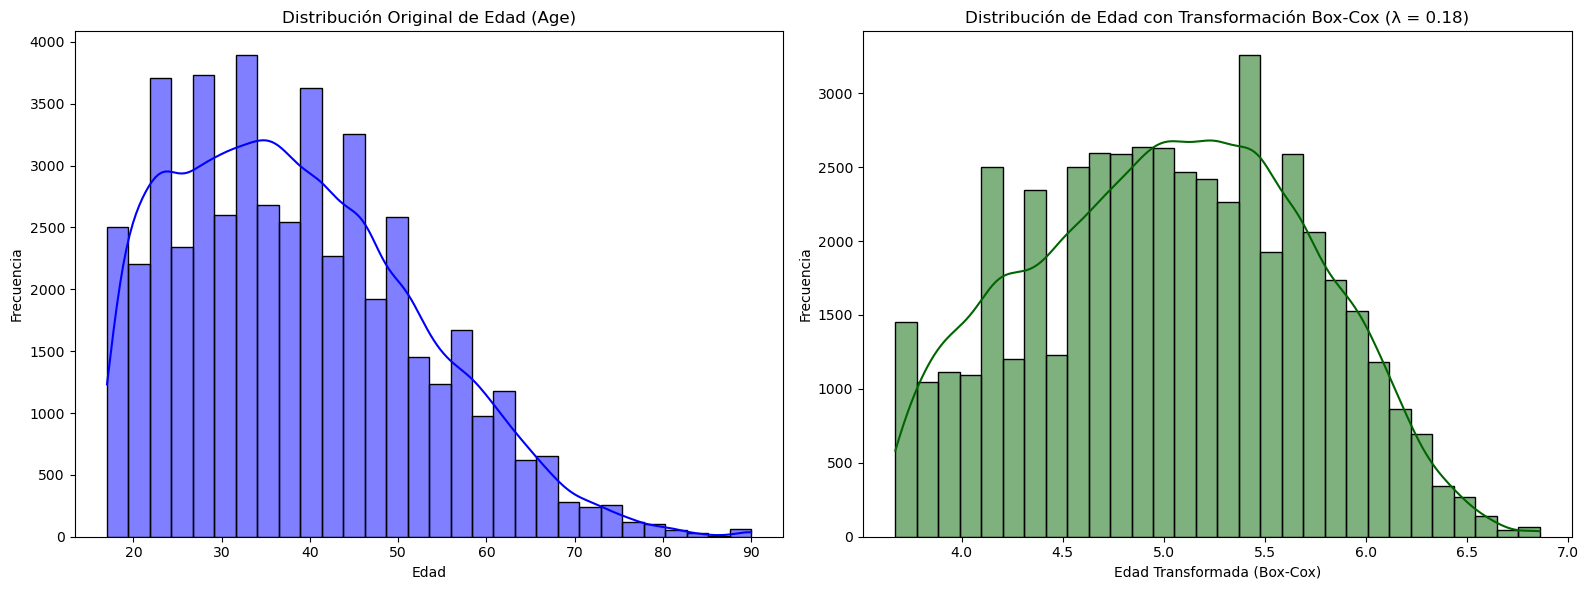

In [28]:
from scipy.stats import boxcox

# 1. Aplicamos la transformación Box-Cox a la variable age
# boxcox nos devuelve la serie transformada y el valor de lambda óptimo encontrado
df_raw['age_boxcox'], lam = boxcox(df_raw['age'])

print(f"Lambda (λ) óptimo calculado para age: {lam:.4f}")

# 2. Creamos la figura comparativa con dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Izquierdo: Distribución Original
sns.histplot(df_raw['age'], kde=True, ax=axes[0], color='blue', bins=30)
axes[0].set_title('Distribución Original de Edad (Age)')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Gráfico Derecho: Distribución con Box-Cox
sns.histplot(df_raw['age_boxcox'], kde=True, ax=axes[1], color='darkgreen', bins=30)
axes[1].set_title(f'Distribución de Edad con Transformación Box-Cox (λ = {lam:.2f})')
axes[1].set_xlabel('Edad Transformada (Box-Cox)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Vemos que si se ha corregido ligeramente la distribución

## Categóricas

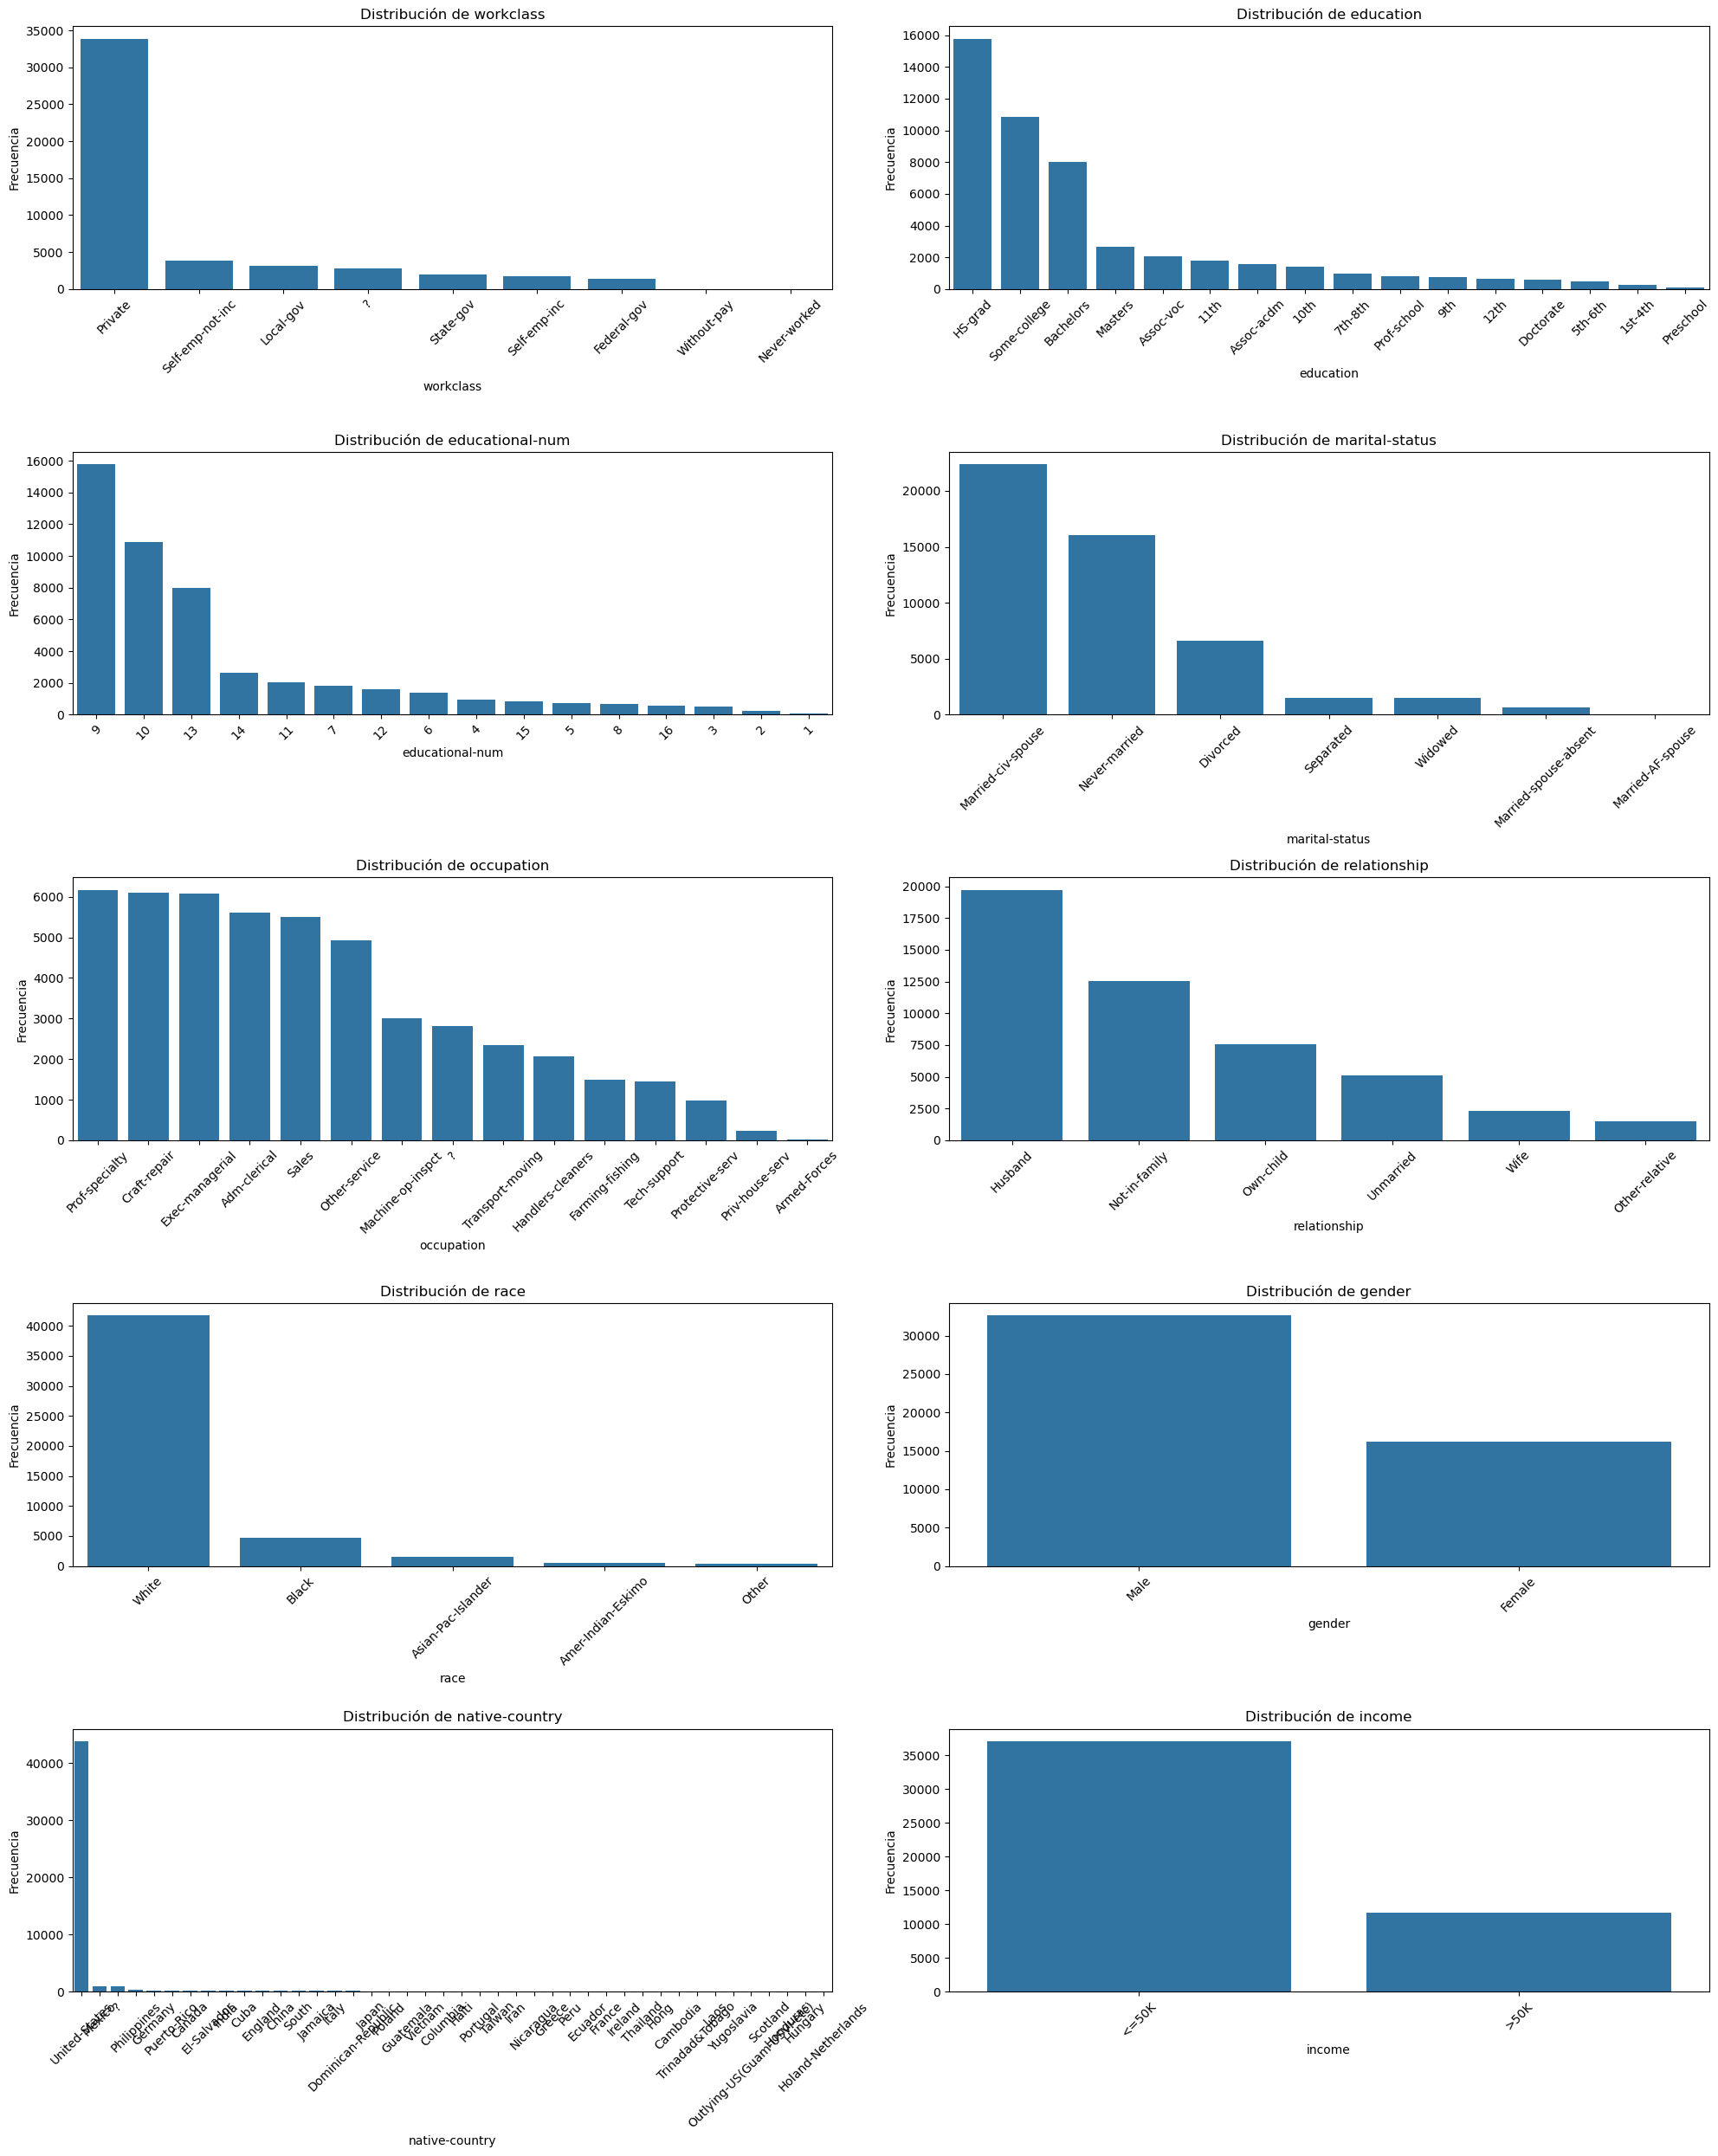

In [29]:
fig, axs = plt.subplots(nrows=len(str_cols) // 2 + len(str_cols) % 2, ncols=2, figsize=(20, 5 * (len(str_cols) // 2 + len(str_cols) % 2)))

# Aplanar el array de ejes para iterar fácilmente
axs = axs.flatten()

for i, col in enumerate(str_cols):
    sns.countplot(data=df_raw, x=col, order=df_raw[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Eliminar subplots vacíos si el número de columnas es impar
if len(str_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

Podemos ver que tenemso columnas con alta cardinalidad como 'native-country', 'occupation', y 'education' aunque esta última ya tiene un campo códificado en formato numérico. También podemos notar cierta redundancia entre el campo 'relationship' y 'marital-status', esto es algo que tendremos que revisar mas adelante para descartar una posible multicolinealidad.

Agrupación para país: Observamos que en la variable de 'native_country' hay una diferencia de frecuencia muy grande entre EEUU y el resto de paises. Al presentar una cardinalidad media alta, vamos a agruparlos por EEUU y Otros para reducir la cardinalidad.

In [30]:
df_raw['native-country'].value_counts(normalize=True)*100

native-country
United-States                 89.756098
Mexico                         1.932773
?                              1.754458
Philippines                    0.602582
Germany                        0.422218
Puerto-Rico                    0.377126
Canada                         0.373027
El-Salvador                    0.317688
India                          0.309490
Cuba                           0.282845
England                        0.260299
China                          0.250051
South                          0.235704
Jamaica                        0.217258
Italy                          0.215208
Dominican-Republic             0.211109
Japan                          0.188563
Poland                         0.178315
Guatemala                      0.176266
Vietnam                        0.176266
Columbia                       0.174216
Haiti                          0.153720
Portugal                       0.137323
Taiwan                         0.133224
Iran                     

In [31]:
# Agrupación binaria para el país
df_raw['country_grouped'] = np.where(df_raw['native-country'] == 'United-States', 'United-States', 'Other')

# Comprobamos cómo queda el reparto
print(df_raw['country_grouped'].value_counts(normalize=True) * 100)

country_grouped
United-States    89.756098
Other            10.243902
Name: proportion, dtype: float64


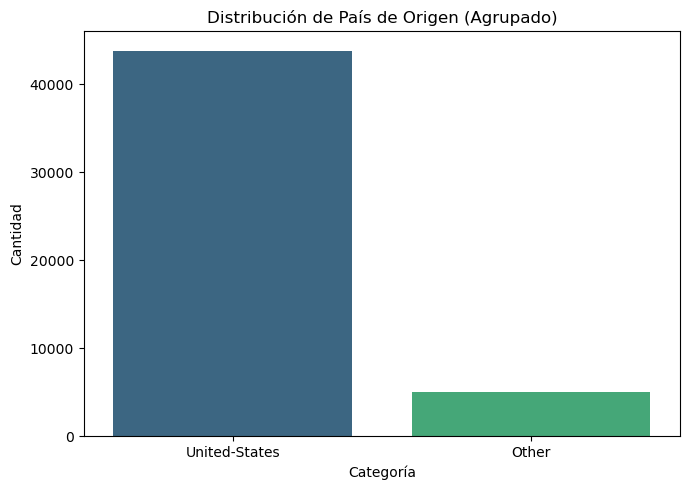

In [32]:


# Configuración básica
plt.figure(figsize=(7, 5))

# Gráfico de barras simple
sns.countplot(
    data=df_raw, 
    x='country_grouped', 
    palette='viridis', 
    order=['United-States', 'Other']
)

# Etiquetas esenciales
plt.title('Distribución de País de Origen (Agrupado)')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

# Análisis Bivariable

**Colunas Numéricas**

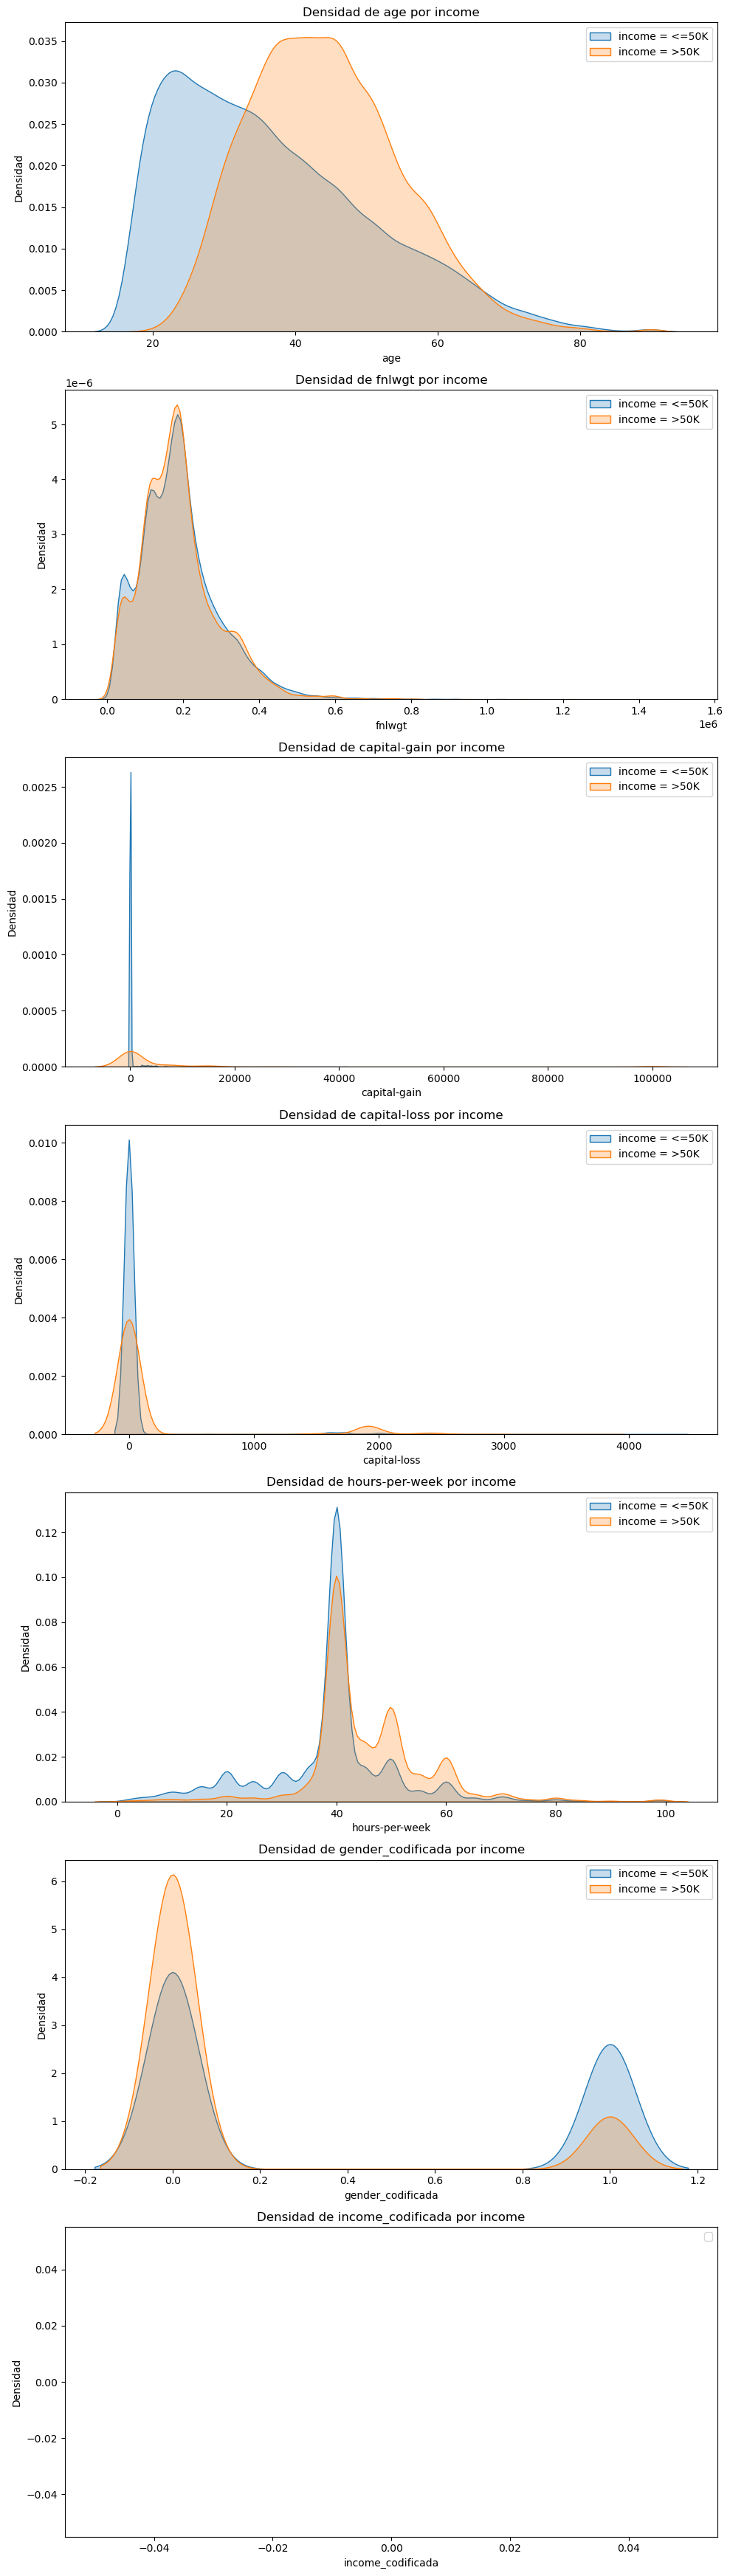

In [33]:
target = 'income'

fig, axs = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(10, 5 * len(numeric_cols)))

#Graficar cada columna numérica contra el target en un subplot
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df_raw[df_raw[target] == df_raw[target].unique()[0]], x=col, ax=axs[i], label=f'{target} = {df_raw[target].unique()[0]}', fill=True)
    sns.kdeplot(data=df_raw[df_raw[target] == df_raw[target].unique()[1]], x=col, ax=axs[i], label=f'{target} = {df_raw[target].unique()[1]}', fill=True)
    axs[i].set_title(f'Densidad de {col} por {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

En la primera gráfica, se observa que las personas en un rango de edad de 40-45 años, tienen salarios más elevados respecto o en comparación a las personas entre los 20-34 años. Esto puede reflejar que la estabilidad financiera llega con los años. La gráfica de 'Capital Gain' y 'Capital Loss', hay que volver a verlas puesto que no se aprecian bien, sin el 0 ya que supone el 95,33% del dataset. A priori observamos que aquellas personas que cobran menos son aquellas que no suelen tener ganancias o pérdidas monetarias en los últimos 12 meses, ya que al tener un ingreso más justo, cabe la posibilidad de que no tengan dinero extra para poder invertir como aquellas que si tienen la capacidad. Finalmente, en la última gráfica 'hours-per-week', en las 40 horas, podemos ver que hay un aumento significativo a aquellos que tienen un salario menor de 50k a diferencia de los que ganan más, pero a medida que van aumentando el número de horas, podemos ver que las personas que cobran más le echan muchas más horas que aquellas que no. Y para los que trabajan menos horas a la semana, es lógico que ganen menos ya que pueden estar trabajando a media jornada o son becarios. 

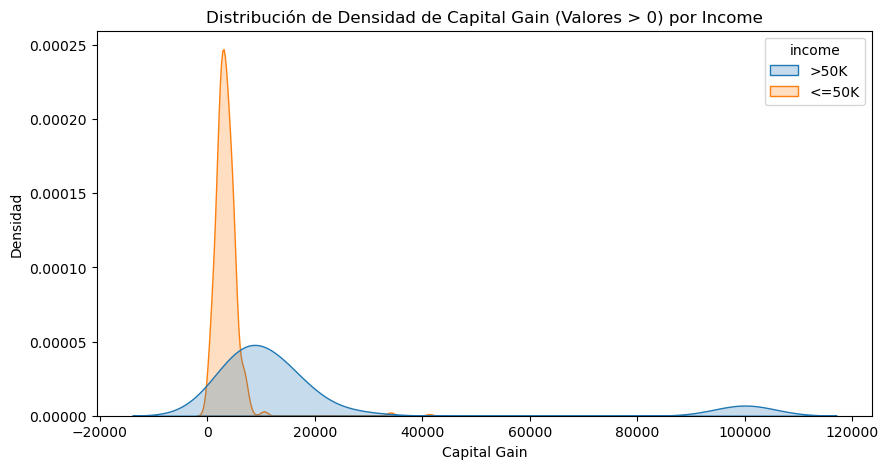

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GRÁFICO 1: CAPITAL GAIN ---
# Filtramos el dataset para quedarnos solo con capital-gain > 0
df_gain = df_raw[df_raw['capital-gain'] > 0]

# Creamos una figura independiente
plt.figure(figsize=(10, 5))

# Graficamos la densidad segmentada por income
sns.kdeplot(
    data=df_gain, 
    x='capital-gain', 
    hue='income', 
    fill=True,
    common_norm=False
)

# Ajustes estéticos
plt.title('Distribución de Densidad de Capital Gain (Valores > 0) por Income')
plt.xlabel('Capital Gain')
plt.ylabel('Densidad')
plt.show()

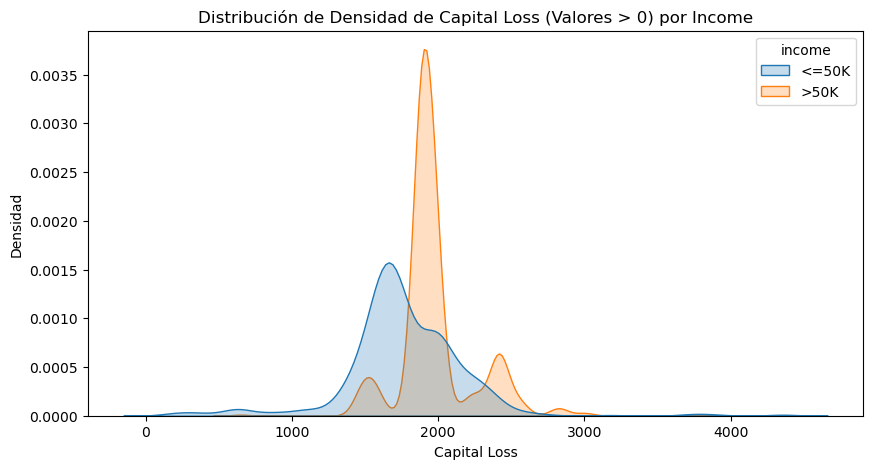

In [35]:
# --- GRÁFICO 2: CAPITAL LOSS ---
# Filtramos el dataset para quedarnos solo con capital-loss > 0
df_loss = df_raw[df_raw['capital-loss'] > 0]

# Creamos otra figura independiente
plt.figure(figsize=(10, 5))

# Graficamos la densidad segmentada por income
sns.kdeplot(
    data=df_loss, 
    x='capital-loss', 
    hue='income', 
    fill=True,
    common_norm=False
)

# Ajustes estéticos
plt.title('Distribución de Densidad de Capital Loss (Valores > 0) por Income')
plt.xlabel('Capital Loss')
plt.ylabel('Densidad')
plt.show()

Tomando en cuenta que la gente con salarios más alto, tienden a invertir más por lo que ganan más y tienen más riesgo a perder, en comparación con aquellos que tienen un salario más bajo. La conclusión a la que hemos llegado para estas dos variables es la de crear una nueva variable que sea la resta de estas dos (capital gain - capital loss), que va a ser el beneficio para encontrar una respuesta más clara.

**Resta Capital gain - Capital Loss**

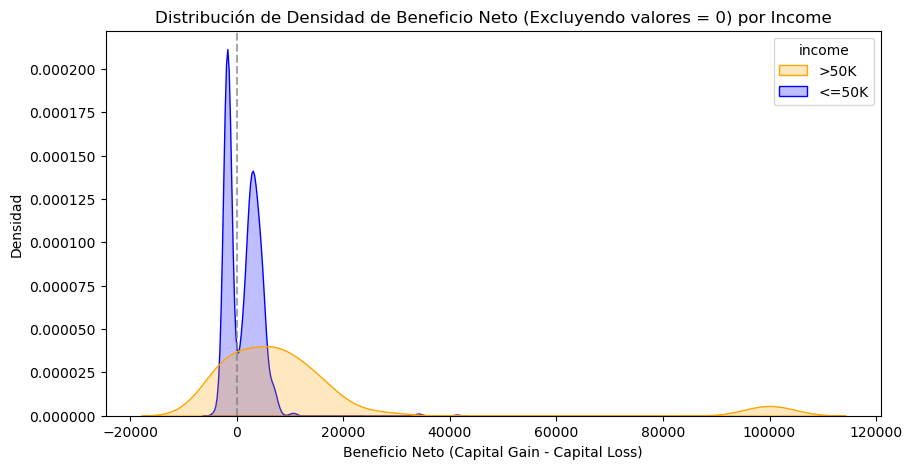

In [36]:
# 1. Calculamos la nueva columna 'Beneficio' (usando guiones como en tus columnas originales)
df_raw['Beneficio'] = df_raw['capital-gain'] - df_raw['capital-loss']

# 2. Filtramos para excluir los valores iguales a 0 (mantenemos ganancias y pérdidas netas)
df_beneficio_nonzero = df_raw[df_raw['Beneficio'] != 0]

# Definimos la paleta de colores que pediste antes
colores_income = {'<=50K': 'blue', '>50K': 'orange'}

# 3. Creamos la figura independiente
plt.figure(figsize=(10, 5))

# Graficamos la densidad segmentada por income
sns.kdeplot(
    data=df_beneficio_nonzero, 
    x='Beneficio', 
    hue='income', 
    palette=colores_income,
    fill=True,
    common_norm=False
)

# Ajustes estéticos
plt.title('Distribución de Densidad de Beneficio Neto (Excluyendo valores = 0) por Income')
plt.xlabel('Beneficio Neto (Capital Gain - Capital Loss)')
plt.ylabel('Densidad')

# Añadimos una línea vertical en 0 para separar visualmente las pérdidas de las ganancias
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

plt.show()

La gráfica demuestra que el beneficio neto de capital es un factor determinante del nivel de ingresos: mientras que las personas con ingresos menores o iguales a 50K (curva azul) se concentran fuertemente alrededor del cero con ganancias o pérdidas mínimas, la población con ingresos superiores a 50K (curva naranja) exhibe una distribución ampliamente dispersa hacia la derecha, revelando que las ganancias de capital medianas, grandes y extremas (de hasta $100,000) son un comportamiento prácticamente exclusivo de este sector adinerado, lo que convierte a esta variable en un predictor clave para tu modelo.

**Crear Variable Beneficio**: 
Dado que las personas con salarios más altos disponen de mayor liquidez para invertir (lo que incrementa tanto sus ganancias potenciales como su exposición al riesgo), analizar capital-gain y capital-loss de forma aislada dispersa la información. Por ello, se creó la variable sintética Beneficio (capital-gain - capital-loss), la cual consolida el resultado financiero neto y ofrece un predictor mucho más claro y potente para el modelo.

**Columnas Categóricas**

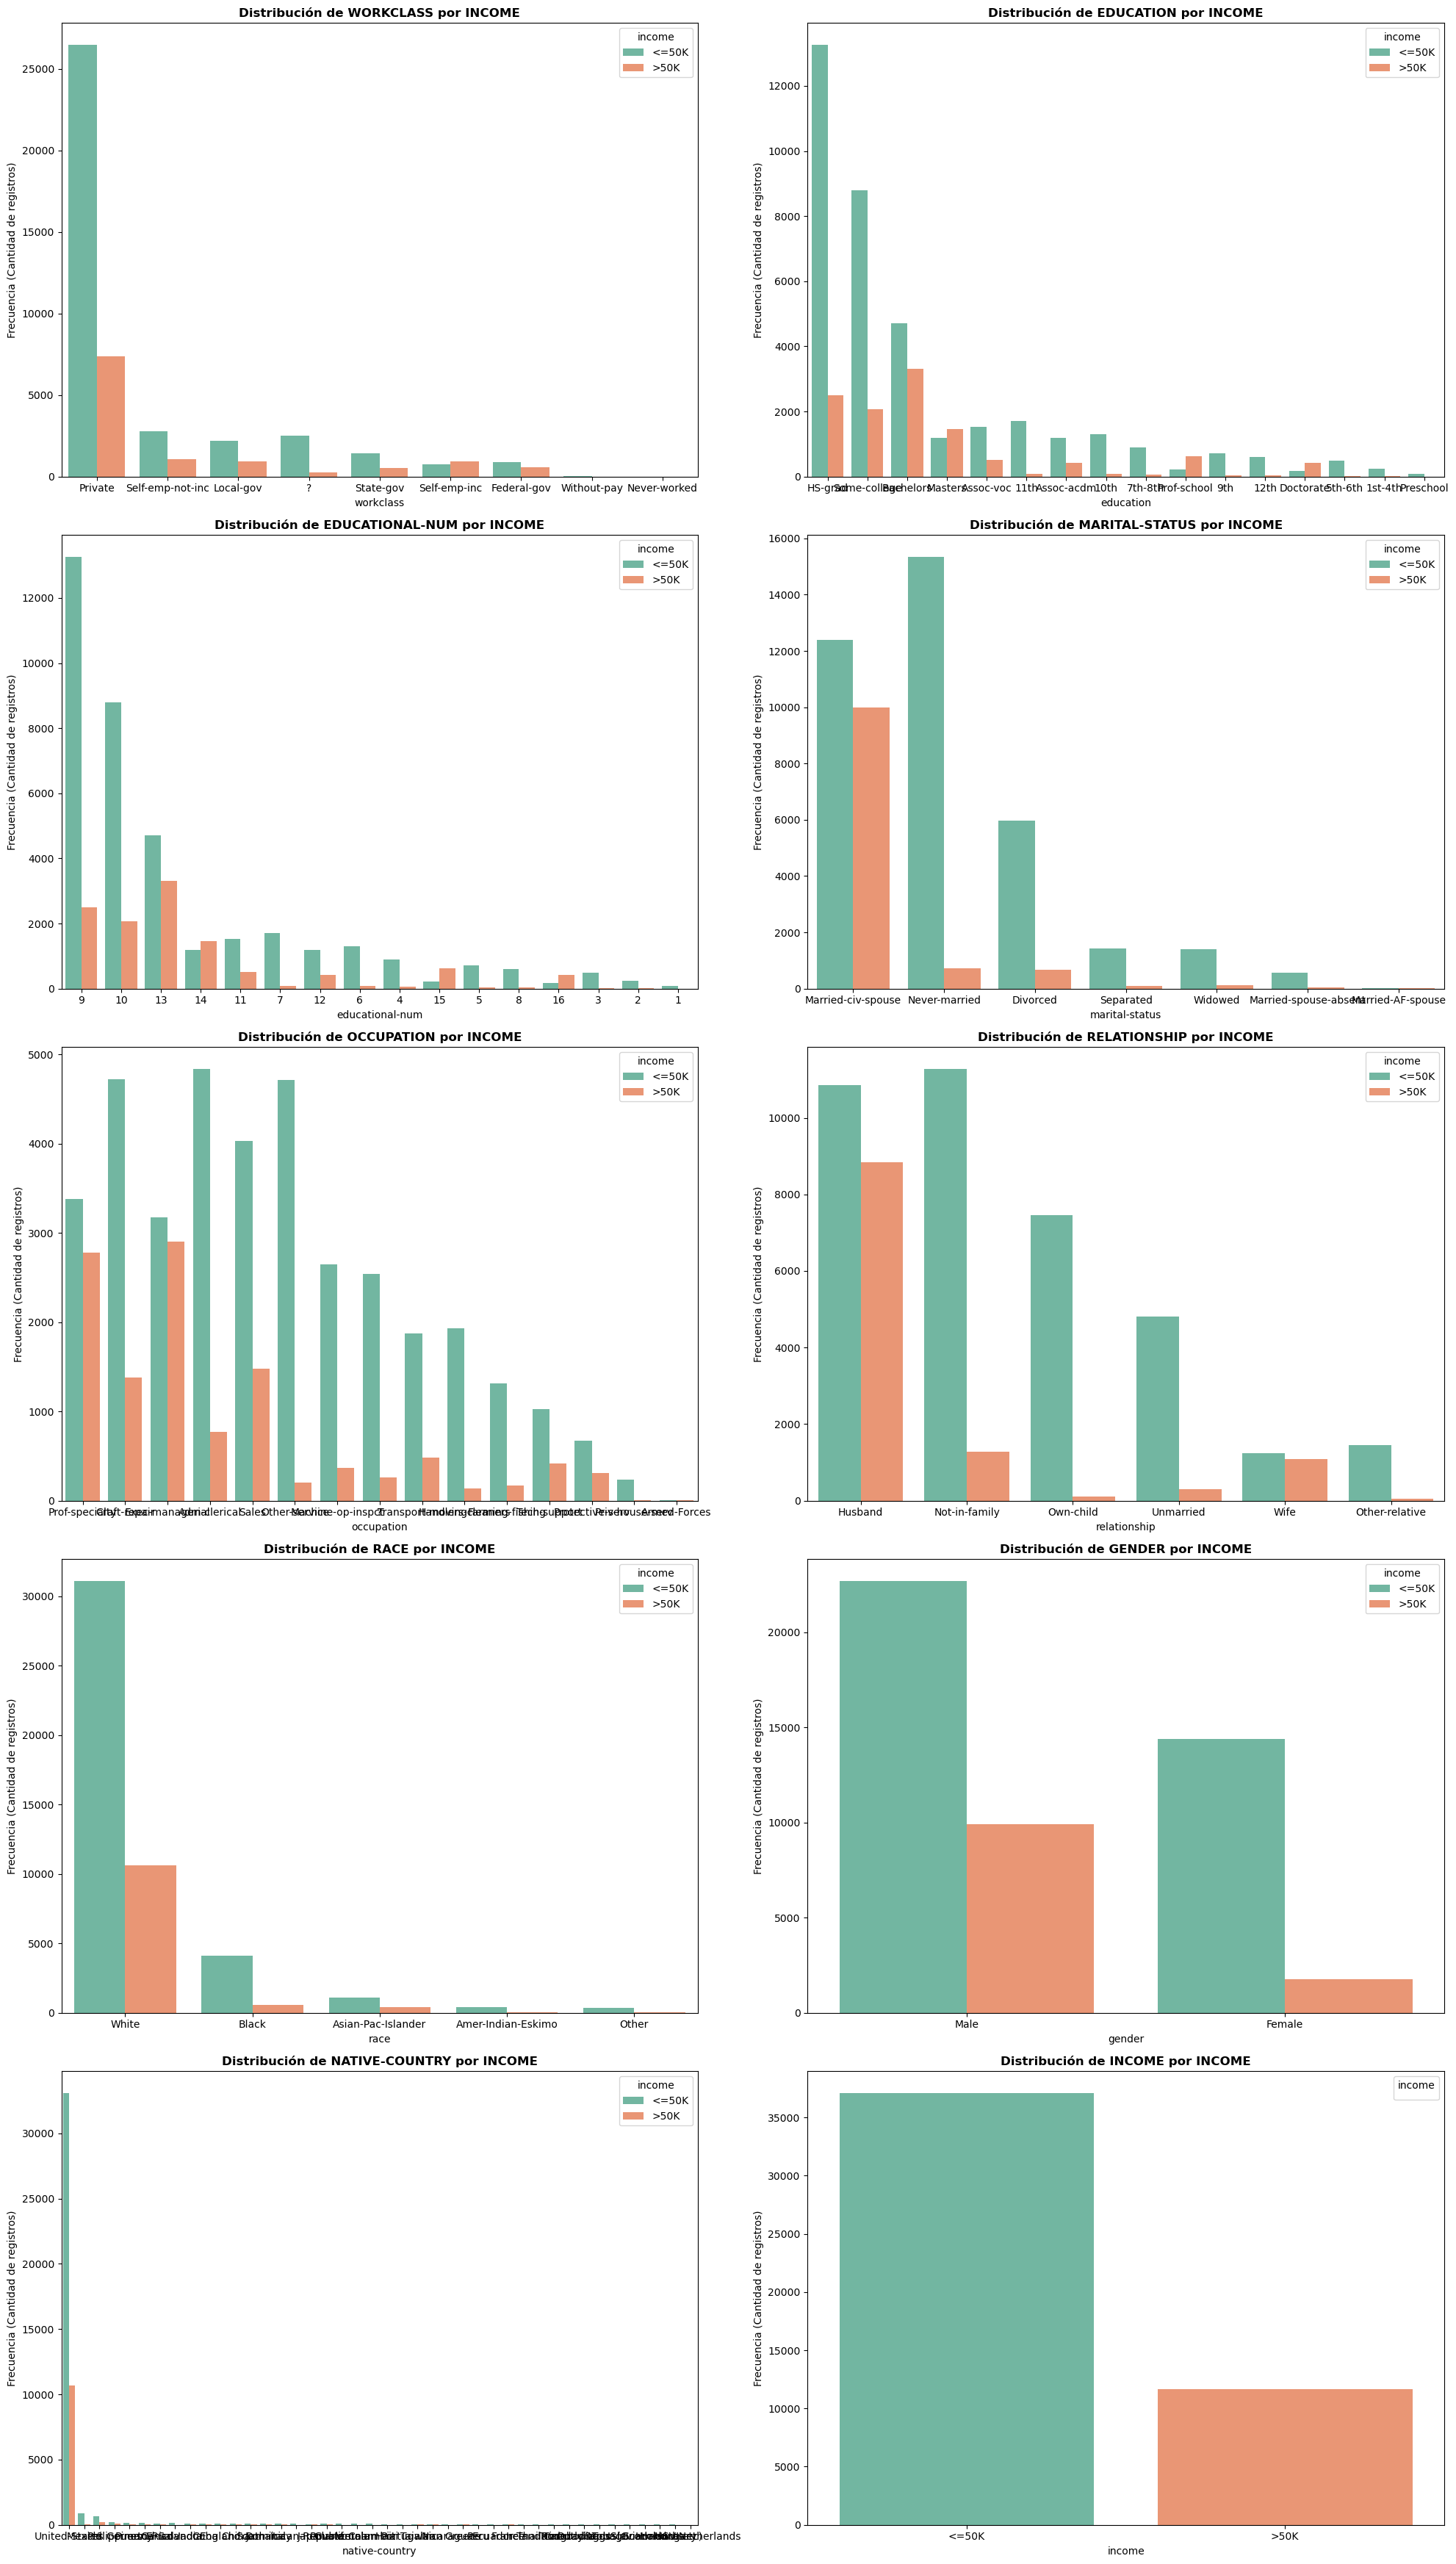

In [37]:
target = 'income'

#Configuración de la cuadrícula (se mantiene tu lógica de filas y columnas)
nrows = len(str_cols) // 2 + len(str_cols) % 2
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(20, 7 * nrows))

#Aplanar el array de ejes para iterar fácilmente
axs = axs.flatten()

for i, col in enumerate(str_cols):
    # Ordenamos las categorías por su frecuencia global para mantener el orden limpio
    order = df_raw[col].value_counts().index

#CAMBIO CLAVE: Usamos y=col (barras horizontales) y añadimos hue=target
    sns.countplot(
        data=df_raw, 
        x=col, 
        order=order, 
        hue=target, 
        ax=axs[i], 
        palette='Set2'
    )

#Títulos y etiquetas adaptadas
    axs[i].set_title(f'Distribución de {col.upper()} por {target.upper()}', fontsize=12, fontweight='bold')
    axs[i].set_ylabel('Frecuencia (Cantidad de registros)')
    axs[i].set_xlabel(col)

#Ya no necesitas rotar las etiquetas de las X porque los textos quedan en el eje Y horizontal
    axs[i].legend(title=target)

#Eliminar subplots vacíos si el número de columnas es impar
if len(str_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()


# Análisis Multivariable

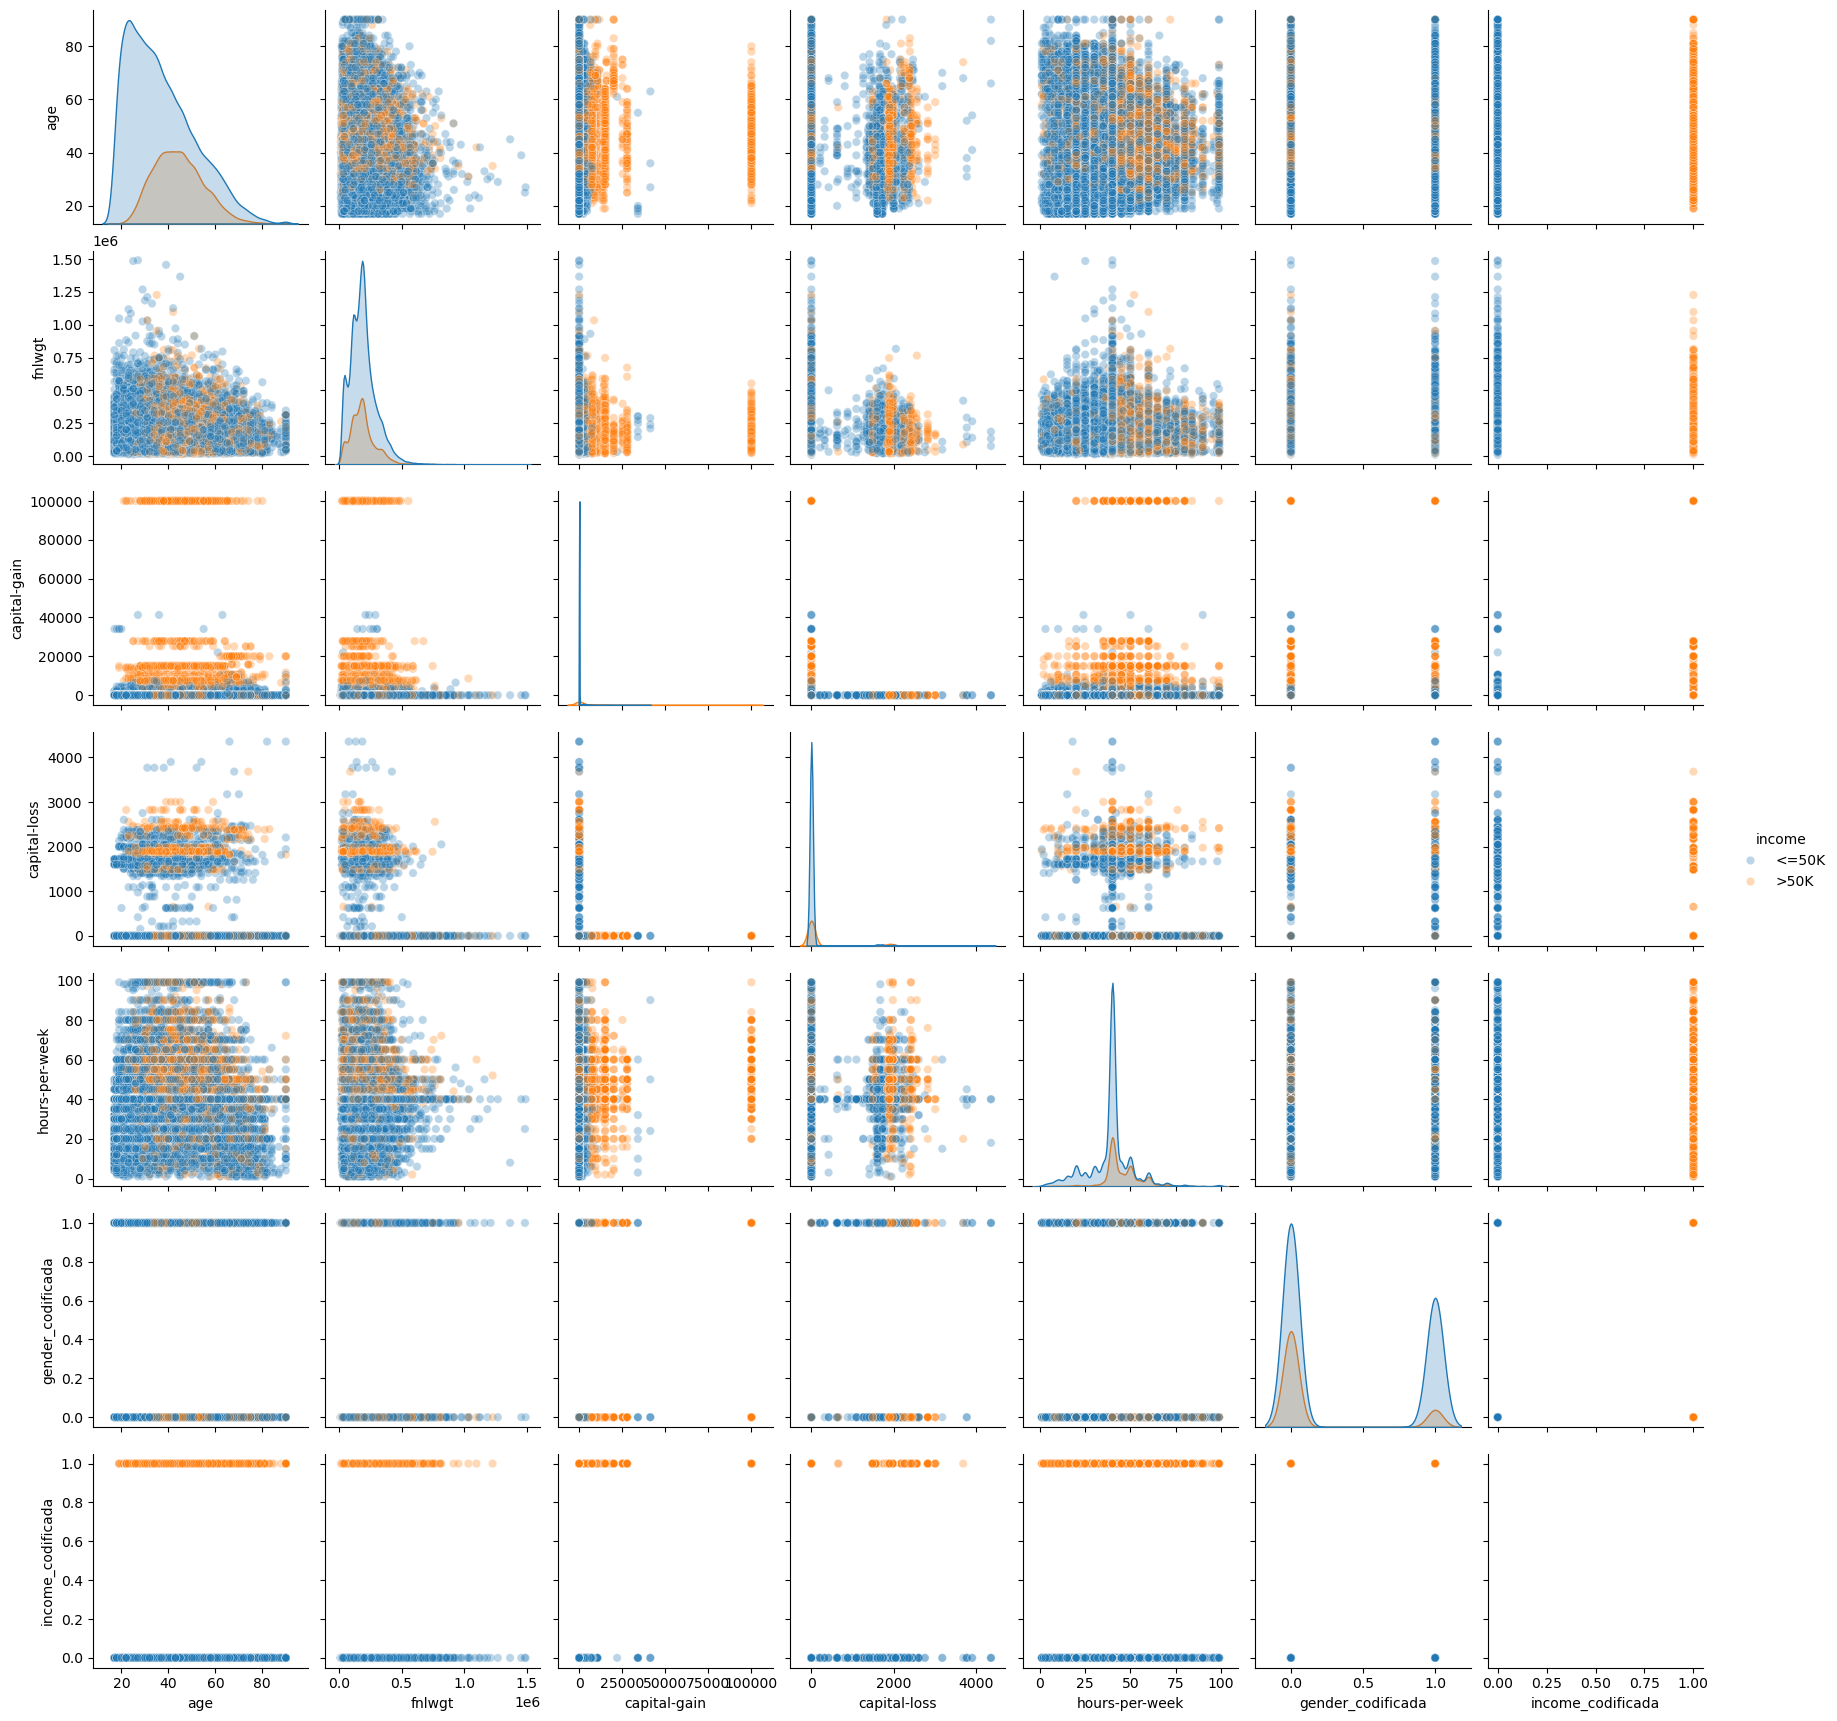

In [38]:
sns.pairplot(df_raw[numeric_cols + ['income']], hue='income', diag_kind='kde', plot_kws={'alpha': 0.3});

In [39]:
# Creamos un subset del dataframe original
df_corr = df_raw[numeric_cols]

# 2. Calculamos las matrices de correlación
pearson_matrix = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')

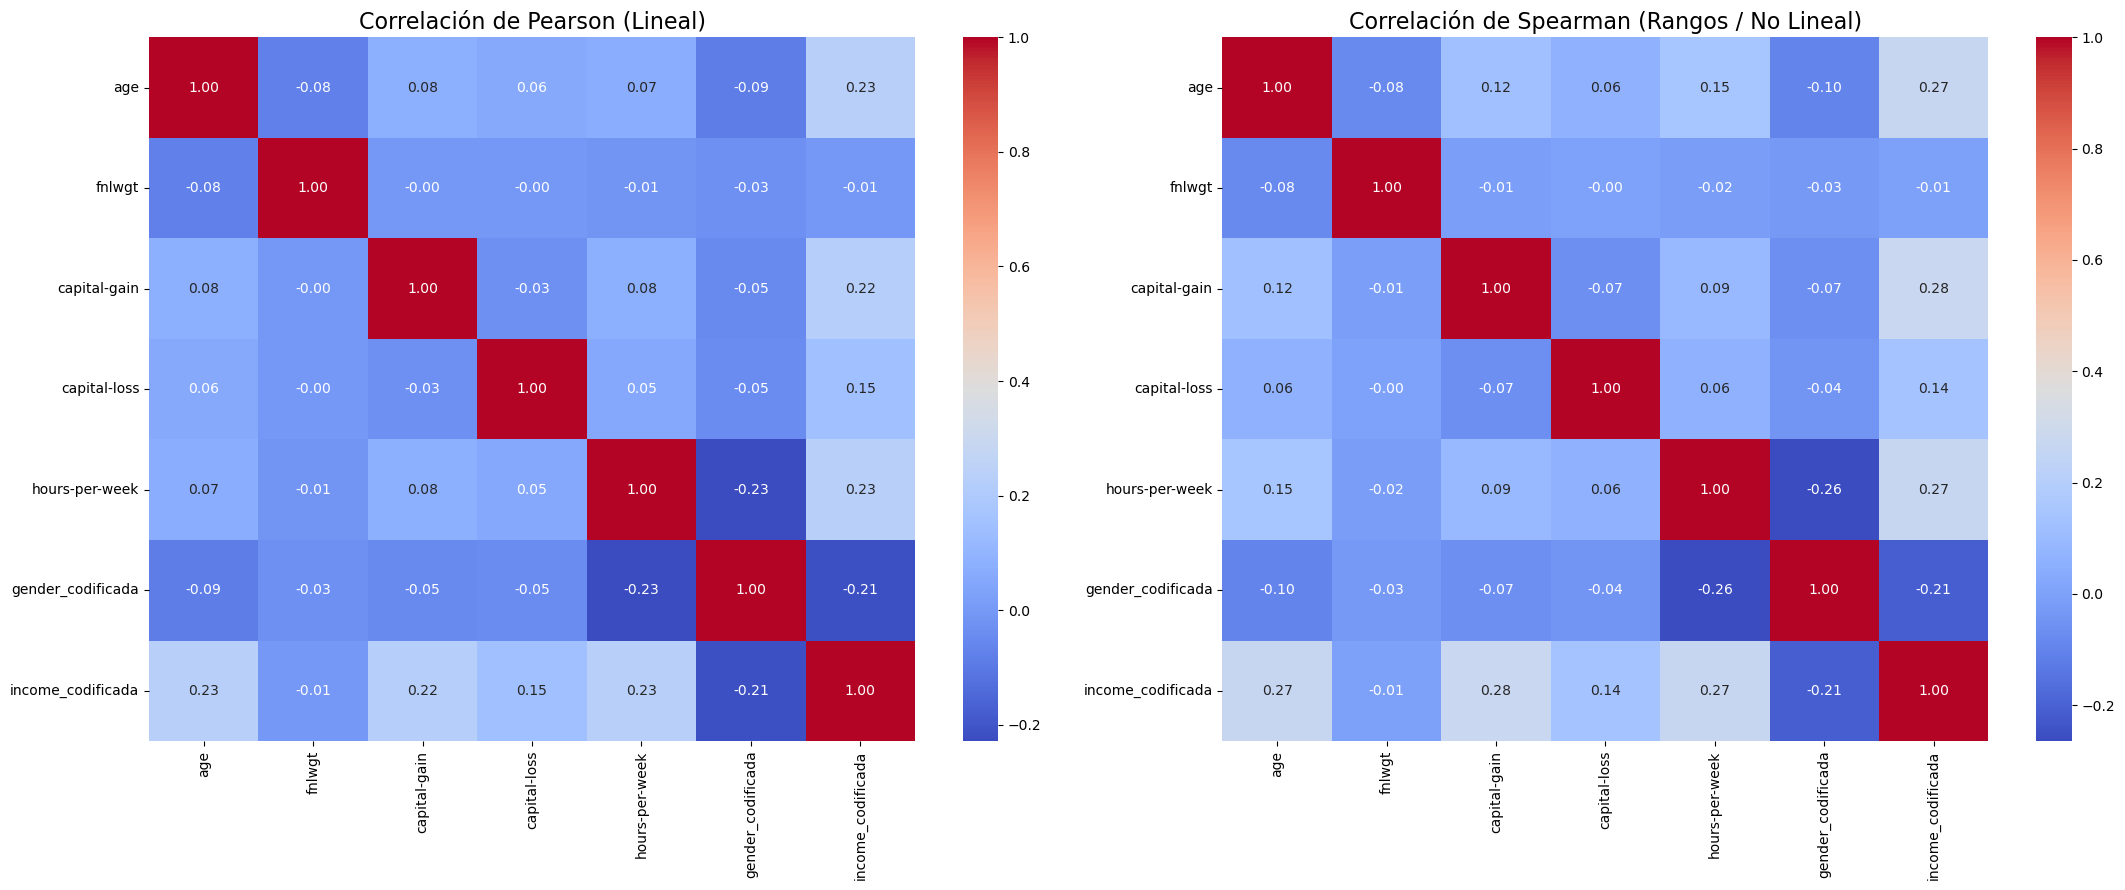

In [40]:
# 3. Configuramos la figura con dos subplots (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap de Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0], cbar=True)
ax[0].set_title('Correlación de Pearson (Lineal)', fontsize=16)

# Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Correlación de Spearman (Rangos / No Lineal)', fontsize=16)

plt.tight_layout()
plt.show()

In [41]:
print("--- Correlación de Spearman con el Income (income_codificada) ---")
print(spearman_matrix['income_codificada'].sort_values(ascending=False))

--- Correlación de Spearman con el Income (income_codificada) ---
income_codificada    1.000000
capital-gain         0.277762
age                  0.269128
hours-per-week       0.268162
capital-loss         0.138233
fnlwgt              -0.005908
gender_codificada   -0.214639
Name: income_codificada, dtype: float64


In [67]:
print("--- Correlación de Pearson con el Income (income_codificada) ---")
print(pearson_matrix['income_codificada'].sort_values(ascending=False))

--- Correlación de Pearson con el Income (income_codificada) ---
income_codificada    1.000000
age                  0.230144
hours-per-week       0.227664
capital-gain         0.223047
capital-loss         0.147542
fnlwgt              -0.006309
gender_codificada   -0.214639
Name: income_codificada, dtype: float64


Los resultados de correlación revelan que las variables financieras y demográficas tradicionales son los motores clave del ingreso: a mayor ganancia de capital (capital-gain), madurez laboral (age) y horas trabajadas por semana (hours-per-week), aumenta notablemente la probabilidad de ganar más de 50K. Por otro lado, la correlación negativa de gender_codificada (-0.21) delata la brecha salarial del censo, indicando que las mujeres (codificadas con 1) tienen estadísticamente menor probabilidad de registrar ingresos altos que los hombres (codificados con 0). Finalmente, es rotundamente recomendable eliminar fnlwgt, ya que su correlación es nula (-0.006) al ser un peso estadístico regional del censo que solo aporta ruido y carece de valor predictivo sobre la capacidad económica individual.

**info Mutua**

In [43]:
# 1. Selección robusta de numéricas
# Nos aseguramos de que 'numeric_cols' contenga solo las columnas que realmente existen
columnas_existentes = [col for col in numeric_cols if col in df_raw.columns]
numeric_features = df_raw[columnas_existentes].copy()

# 2. Eliminación de la columna objetivo (Target) y de texto sobrante
numeric_features = numeric_features.drop(columns=['income_codificada', 'income'], errors='ignore')

# 3. Tratamiento de nulos (Imputación simple para el análisis)
X = numeric_features.fillna(0)
y = df_raw['income_codificada'].fillna(0).astype(int) # Aseguramos que sea entero para clasificación

# 4. Cálculo de Información Mutua para Clasificación
print("Calculando relevancia de variables...")
mi_scores = mutual_info_classif(X, y, random_state=42)  # <--- Cambiado aquí también

# 5. Formateo de resultados
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\nRanking de importancia de variables numéricas:")
print(mi_results)

Calculando relevancia de variables...

Ranking de importancia de variables numéricas:
capital-gain         0.083180
age                  0.065462
hours-per-week       0.040857
fnlwgt               0.038593
capital-loss         0.035507
gender_codificada    0.032519
dtype: float64


Los puntajes de Información Mutua confirman que capital-gain (0.083) y age (0.065) son los predictores que más información comparten con el nivel de ingresos, consolidándose como las variables numéricas más determinantes para el modelo. A diferencia de la correlación lineal tradicional, la Información Mutua captura dependencias más complejas y no lineales, lo que explica por qué variables como fnlwgt (0.038), capital-loss (0.035) y gender_codificada (0.032) muestran ahora niveles de relevancia bastante similares entre sí. Sin embargo, aunque fnlwgt registre un valor matemáticamente superior a cero debido a la dispersión de sus datos, la recomendación de eliminarla se mantiene firme, ya que ese puntaje es puro ruido estadístico derivado de su alta variedad numérica y carece por completo de una justificación lógica o causal con la capacidad económica de los individuos.

**Variables Categóricas**

In [68]:
resultados = []

print("--- Análisis de Chi-Cuadrado vs Income---")

for col in str_cols:
    # Creamos la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(df_raw[col], df_raw['income'])
    
    # Calculamos Chi2 y el p-valor
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Interpretación
    dependiente = "SÍ (Significativa)" if p < 0.05 else "NO (Independiente)"

    resultados.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-valor': f"{p:.4e}", # Formato científico para p-valores muy pequeños
        'Relación con Fraude': dependiente
    })

# 2. Mostramos los resultados en una tabla limpia
df_chi = pd.DataFrame(resultados).sort_values(by='Chi2', ascending=False)
print(df_chi.to_string(index=False))


--- Análisis de Chi-Cuadrado vs Income---
       Variable     Chi2     p-valor Relación con Fraude
         income 48784.51  0.0000e+00  SÍ (Significativa)
   relationship 10070.63  0.0000e+00  SÍ (Significativa)
 marital-status  9797.14  0.0000e+00  SÍ (Significativa)
      education  6536.47  0.0000e+00  SÍ (Significativa)
educational-num  6536.47  0.0000e+00  SÍ (Significativa)
     occupation  5975.47  0.0000e+00  SÍ (Significativa)
         gender  2246.69  0.0000e+00  SÍ (Significativa)
      workclass  1609.50  0.0000e+00  SÍ (Significativa)
           race   487.49 3.4086e-104  SÍ (Significativa)
 native-country   449.41  3.7516e-70  SÍ (Significativa)


El análisis de Chi-cuadrado revela que todas las variables categóricas analizadas tienen una relación estadísticamente significativa con la variable objetivo, ya que todos los p-valores son prácticamente cero (muy inferiores al umbral estándar de 0.05), lo que descarta que estas asociaciones se deban al azar. Al observar la magnitud del estadístico Chi2, que mide la fuerza de la dependencia, se hace evidente un claro orden de relevancia: income lidera de forma masiva el ranking (48,784.51), seguida por el entorno familiar y social (relationship y marital-status), consolidándose como los predictores categóricos con mayor peso y conexión lógica para identificar patrones. En el extremo opuesto, aunque variables como race y native-country siguen siendo estadísticamente significativas debido al gran volumen de datos, sus bajos valores de Chi2 indican que su impacto real o fuerza de asociación es mucho menor en comparación con el perfil socioeconómico y laboral del individuo.

In [45]:
def cramers_v(contingency_table):
    """ Calcula el coeficiente V de Cramer para una tabla de contingencia. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []

print("--- Análisis de Fuerza de Asociación (V de Cramer) ---")

for col in str_cols:
    # Creamos la tabla de contingencia
    contingency_table = pd.crosstab(df_raw[col], df_raw['income'])
    
    # Calculamos V de Cramer
    v = cramers_v(contingency_table)
    
    # Interpretación rápida de la fuerza
    if v > 0.5: fuerza = "Muy Fuerte"
    elif v > 0.3: fuerza = "Fuerte"
    elif v > 0.1: fuerza = "Moderada"
    else: fuerza = "Débil"
    
    resultados_v.append({
        'Variable': col,
        'Cramers V': round(v, 4),
        'Fuerza': fuerza
    })

# Mostramos resultados ordenados por fuerza
df_v = pd.DataFrame(resultados_v).sort_values(by='Cramers V', ascending=False)
print(df_v.to_string(index=False))

--- Análisis de Fuerza de Asociación (V de Cramer) ---
       Variable  Cramers V     Fuerza
         income     0.9999 Muy Fuerte
   relationship     0.4542     Fuerte
 marital-status     0.4480     Fuerte
      education     0.3656     Fuerte
educational-num     0.3656     Fuerte
     occupation     0.3496     Fuerte
         gender     0.2145   Moderada
      workclass     0.1812   Moderada
           race     0.0995      Débil
 native-country     0.0915      Débil


El análisis de Fuerza de Asociación mediante la V de Cramer (excluyendo la variable income) revela que el verdadero núcleo predictivo para el modelo está liderado por el entorno socio-familiar del individuo, donde relationship (0.4542) y marital-status (0.4480) presentan una influencia "Fuerte", seguidas muy de cerca por el nivel de estudios (education) y la ocupación (occupation) con una fuerza también "Fuerte" de ~0.35. Por su parte, gender y workclass muestran una asociación "Moderada", mientras que race y native-country registran una fuerza "Débil" (inferior a 0.10). A pesar de la baja asociación individual de estas dos últimas, no se recomienda eliminarlas en esta etapa; dado que el análisis previo de Chi-cuadrado demostró que son estadísticamente significativas (p-valor < 0.05), aportan sutiles matices demográficos que un modelo de Machine Learning puede aprovechar para mejorar la precisión en subgrupos específicos de la población.

# **Hipótesis (Gráficos hecho por IA)**

1. **Hipótesis de Género**: Los hombres tendrán una mayor probabilidad de superar los 50.000 u.m. debido a las brechas salariales históricas por género.

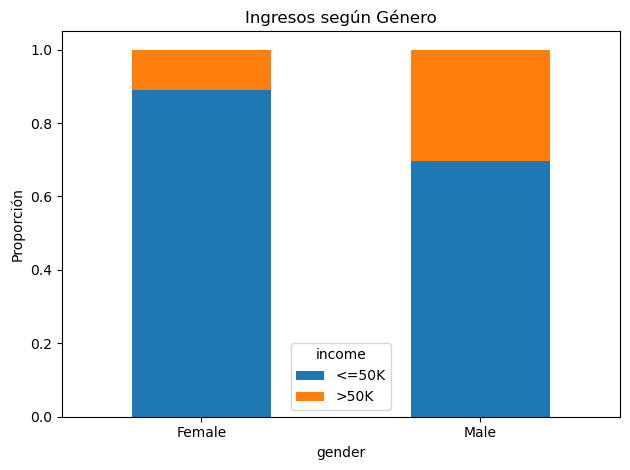

In [46]:
pd.crosstab(df_raw['gender'], df_raw['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Ingresos según Género')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
df_raw.groupby('gender')['income'].apply(lambda x: (x == '>50K').mean())

gender
Female    0.109360
Male      0.303919
Name: income, dtype: float64

**Respuesta:** La diferencia es muy notable. Los hombres tienen una proporción de ingresos >50K significativamente mayor que las mujeres. El género es una variable muy relevante para el modelo.

2. **Hipótesis de Educación**: Las personas con mayor nivel educativo tendrán salarios más altos. Títulos universitarios o de posgrado estarán asociados a ingresos >50K.

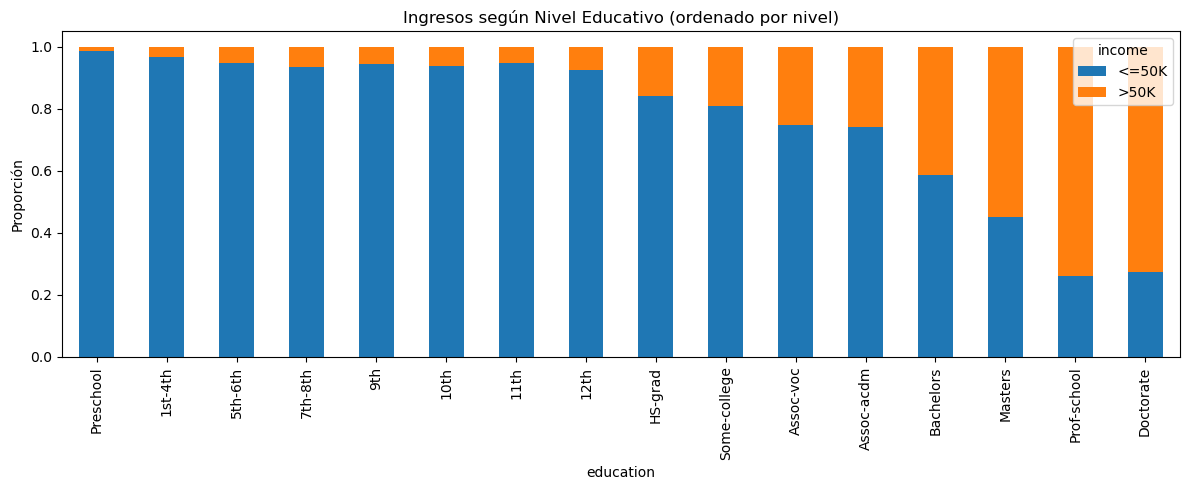

In [48]:
#Ordenar por educational-num para que la visualización tenga sentido
edu_order = df_raw.groupby('education')['educational-num'].mean().sort_values().index

edu_income = pd.crosstab(df_raw['education'], df_raw['income'], normalize='index')
edu_income = edu_income.loc[edu_order]

edu_income.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Ingresos según Nivel Educativo (ordenado por nivel)')
plt.ylabel('Proporción')
plt.tight_layout()
plt.show()

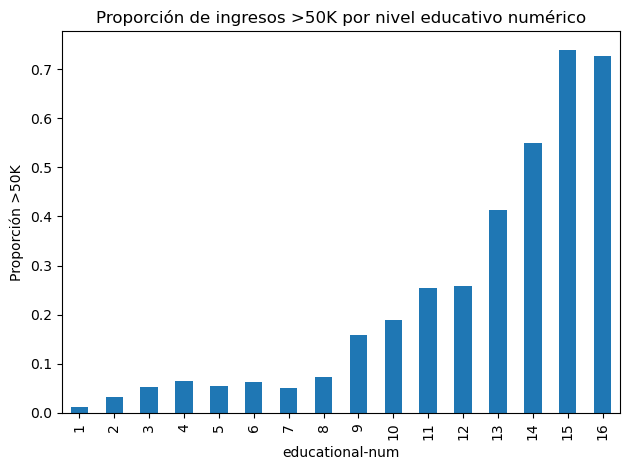

In [49]:
df_raw.groupby('educational-num')['income'].apply(lambda x: (x == '>50K').mean()).plot(kind='bar')
plt.title('Proporción de ingresos >50K por nivel educativo numérico')
plt.ylabel('Proporción >50K')
plt.tight_layout()
plt.show()

**Respuesta:** La hipótesis se confirma claramente: a mayor nivel educativo, mayor proporción de ingresos >50K. Las personas con Doctorate y Prof-school tienen las mayores tasas. educational-num será una de las variables más relevantes del modelo.


3. **Hipótesis de Edad**: Las personas de mayor edad tendrán más experiencia laboral acumulada y, por tanto, mayores ingresos, hasta llegar a un punto de inflexión (jubilación).

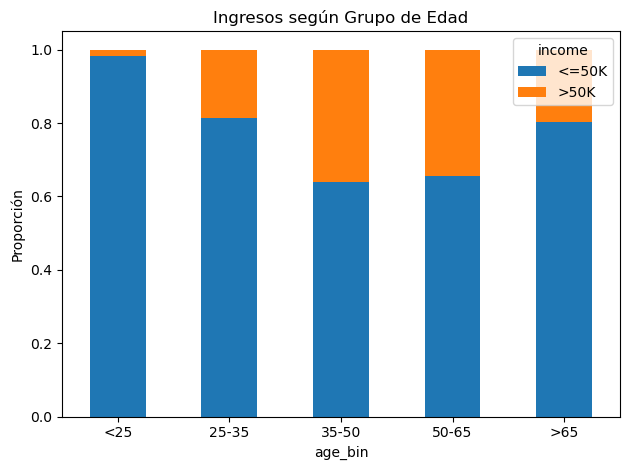

In [50]:
#Crear bins de edad
df_raw['age_bin'] = pd.cut(df_raw['age'], bins=[0, 25, 35, 50, 65, 100],
                              labels=['<25', '25-35', '35-50', '50-65', '>65'])

pd.crosstab(df_raw['age_bin'], df_raw['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Ingresos según Grupo de Edad')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

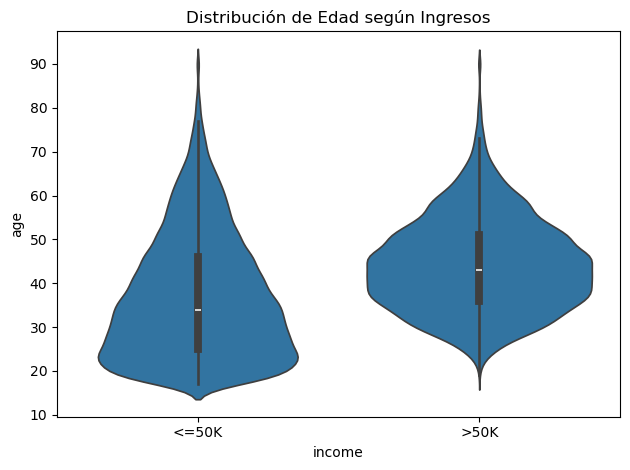

In [51]:
sns.violinplot(x='income', y='age', data=df_raw)
plt.title('Distribución de Edad según Ingresos')
plt.tight_layout()
plt.show()

**Respuesta:** La hipótesis se confirma parcialmente: la proporción de ingresos mayores a 50K crece con la edad hasta el grupo 50-65, y luego decrece ( jubilación). La edad es una variable relevante.

4. **Hipótesis de Estado Civil**: Las personas casadas (especialmente Married-civ-spouse) tendrán mayores ingresos, posiblemente por el efecto de selección (parejas con mayor estabilidad económica).

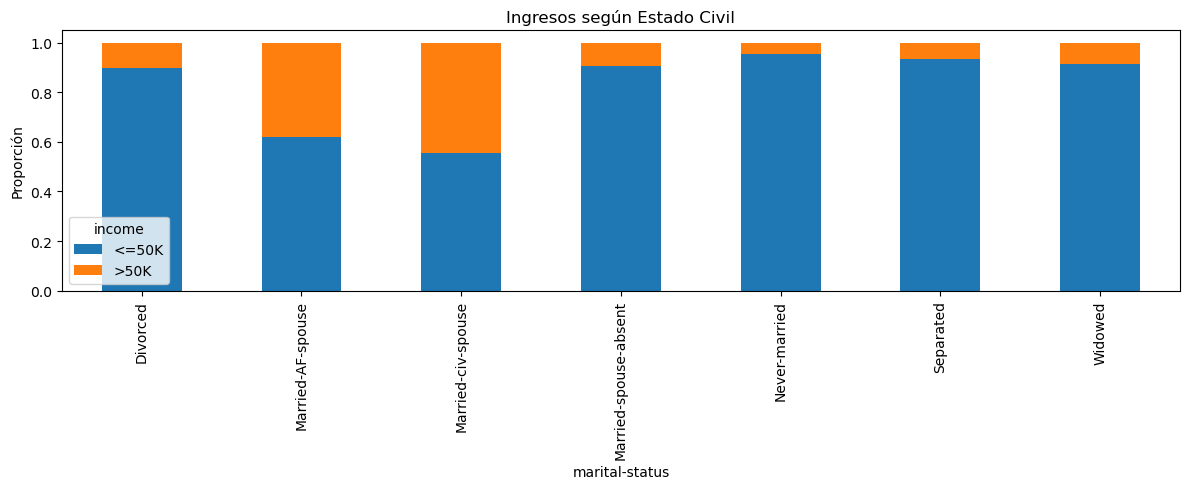

In [52]:
pd.crosstab(df_raw['marital-status'], df_raw['income'], normalize='index').plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Ingresos según Estado Civil')
plt.ylabel('Proporción')
plt.tight_layout()
plt.show()

In [53]:
df_raw.groupby('marital-status')['income'].apply(lambda x: (x == '>50K').mean()).sort_values(ascending=False)

marital-status
Married-civ-spouse       0.446124
Married-AF-spouse        0.378378
Divorced                 0.101207
Married-spouse-absent    0.092504
Widowed                  0.084321
Separated                0.064706
Never-married            0.045579
Name: income, dtype: float64

**Respuesta:** Married-civ-spouse destaca con una proporción de mas de 50K muy superior al resto. El estado civil es una de las variables más discriminativas del dataset.

5. **Hipótesis de Ocupación**: Las ocupaciones ejecutivas y profesionales especializadas (Exec-managerial, Prof-specialty) estarán más asociadas a ingresos altos.

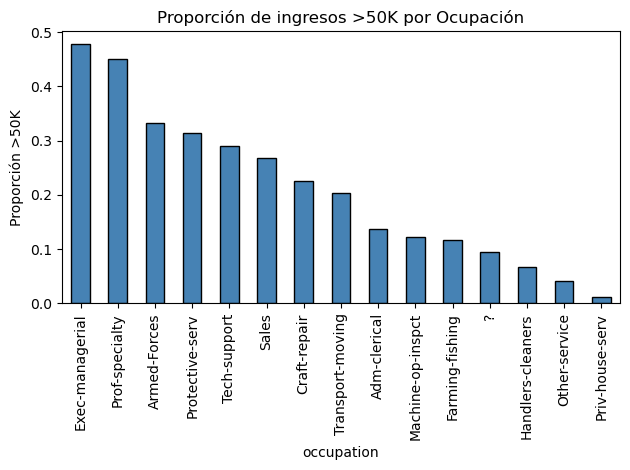

In [54]:
occ_income = df_raw.groupby('occupation')['income'].apply(lambda x: (x == '>50K').mean()).sort_values(ascending=False)
occ_income.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Proporción de ingresos >50K por Ocupación')
plt.ylabel('Proporción >50K')
plt.tight_layout()
plt.show()

**Respuesta:** Exec-managerial y Prof-specialty tienen las mayores tasas de ingresos mayores a 50K. Las ocupaciones como Priv-house-serv y Farming-fishing tienen las tasas más bajas. La ocupación es una variable relevante.

6. **Hipótesis de Horas trabajadas**: Las personas que trabajan más horas semanales tendrán más probabilidad de superar los 50.000 u.m.

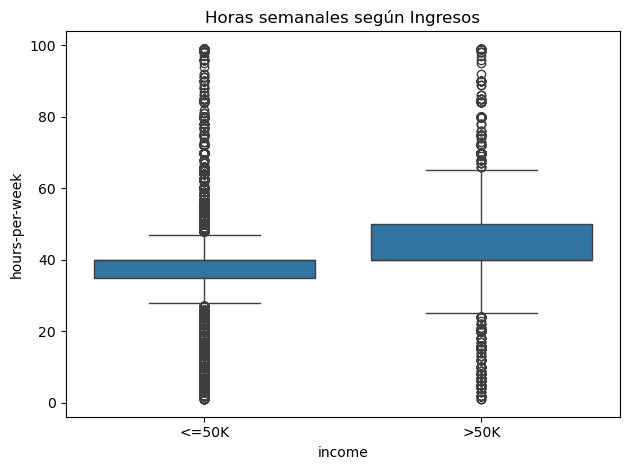

In [55]:
sns.boxplot(x='income', y='hours-per-week', data=df_raw)
plt.title('Horas semanales según Ingresos')
plt.tight_layout()
plt.show()

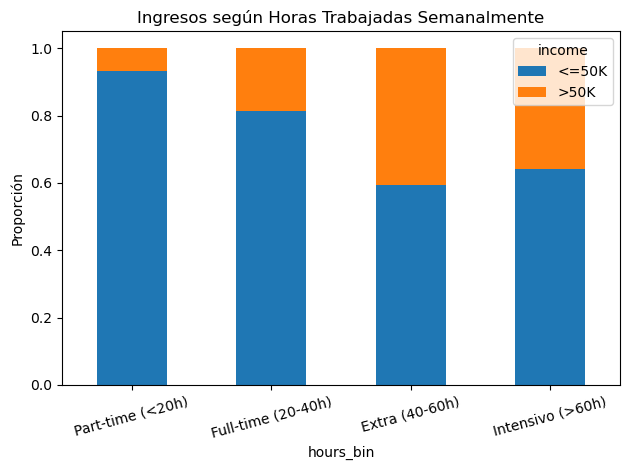

In [56]:
#Bins de horas semanales
df_raw['hours_bin'] = pd.cut(df_raw['hours-per-week'], bins=[0, 20, 40, 60, 100],
                                labels=['Part-time (<20h)', 'Full-time (20-40h)', 'Extra (40-60h)', 'Intensivo (>60h)'])

pd.crosstab(df_raw['hours_bin'], df_raw['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Ingresos según Horas Trabajadas Semanalmente')
plt.ylabel('Proporción')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Respuesta:** Existe una tendencia positiva: más horas semanales implica mayor proporción de ingresos mayores a 50K, aunque la diferencia entre 40h y menos de 60h no es tan pronunciada como cabría esperar.

7. **Hipótesis de Capital**: Las personas con ganancias de capital (capital-gain > 0) tendrán ingresos más altos, ya que estas ganancias suelen estar asociadas a inversiones y patrimonio.

In [57]:
#La mayoría de registros tienen capital-gain = 0, veamos los que sí tienen ganancias
df_raw['has_capital_gain'] = (df_raw['capital-gain'] > 0).astype(int)
df_raw.groupby('has_capital_gain')['income'].apply(lambda x: (x == '>50K').mean())

has_capital_gain
0    0.205340
1    0.617348
Name: income, dtype: float64

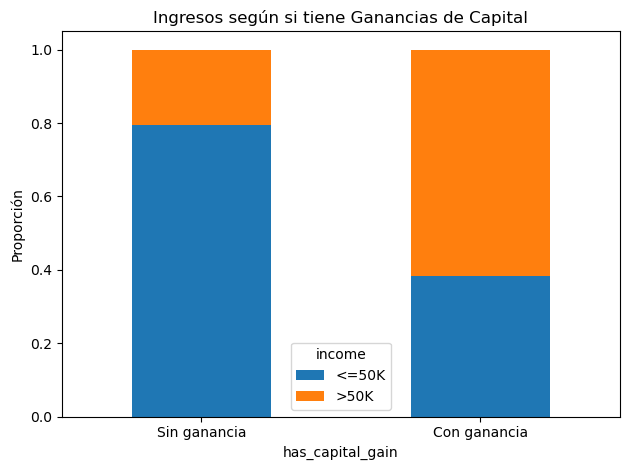

In [58]:
pd.crosstab(df_raw['has_capital_gain'], df_raw['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Ingresos según si tiene Ganancias de Capital')
plt.ylabel('Proporción')
plt.xticks([0, 1], ['Sin ganancia', 'Con ganancia'], rotation=0)
plt.tight_layout()
plt.show()

**Respuesta:** La hipótesis se confirma de forma contundente: las personas con ganancias de capital tienen una proporción de ingresos mayor a 50K muchísimo mayor. capital-gain es una de las variables más informativas del dataset.

8. **Hipótesis de Tipo de empleador**: Los trabajadores del gobierno federal y los autónomos con empresa (Self-emp-inc) tendrán salarios más altos en comparación con los empleados privados.

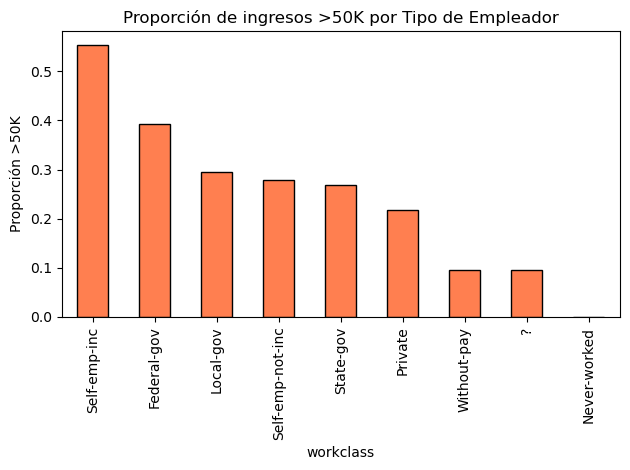

In [59]:
wc_income = df_raw.groupby('workclass')['income'].apply(lambda x: (x == '>50K').mean()).sort_values(ascending=False)
wc_income.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Proporción de ingresos >50K por Tipo de Empleador')
plt.ylabel('Proporción >50K')
plt.tight_layout()
plt.show()

**Respuesta:** Self-emp-inc destaca como el grupo con mayor tasa de ingresos altos. El gobierno federal también muestra una tasa elevada. Por lo que la hipótesis se confirma.

9. **Hipótesis de País de origen**: La mayoría de registros serán de Estados Unidos. Podría existir diferencia entre nativos y no nativos.

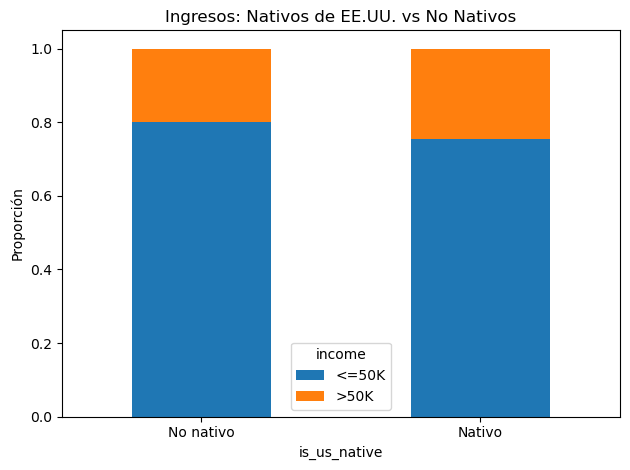

In [60]:
#Simplificamos: nativo vs no nativo
df_raw['is_us_native'] = (df_raw['native-country'] == 'United-States').astype(int)

pd.crosstab(df_raw['is_us_native'], df_raw['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Ingresos: Nativos de EE.UU. vs No Nativos')
plt.ylabel('Proporción')
plt.xticks([0, 1], ['No nativo', 'Nativo'], rotation=0)
plt.tight_layout()
plt.show()


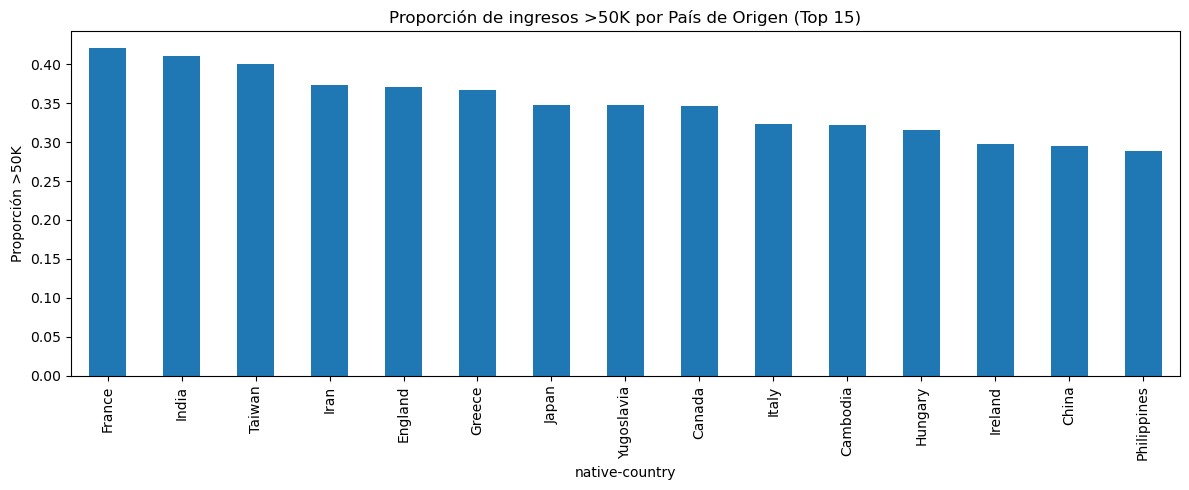

In [61]:
#Top países por proporción de ingresos >50K
country_income = df_raw.groupby('native-country')['income'].apply(lambda x: (x == '>50K').mean())
country_income.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(12, 5))
plt.title('Proporción de ingresos >50K por País de Origen (Top 15)')
plt.ylabel('Proporción >50K')
plt.tight_layout()
plt.show()

**Respuesta:** No existe una diferencia muy significativa entre nativos y no nativos a nivel general. Sin embargo, algunos países tienen tasas muy elevadas, lo cual puede deberse a que hay muy pocos registros de esos países y los resultados no son representativos.

10. **Hipótesis de Interacciones**:
    - **Género y Educación**: Las mujeres con educación universitaria reducirán la brecha salarial respecto a los hombres.
    - **Edad y Ocupación**: Las personas mayores en ocupaciones ejecutivas concentrarán la mayoría de los ingresos altos.
    - **Estado Civil y Género**: Los hombres casados serán el grupo con mayor proporción de ingresos >50K.

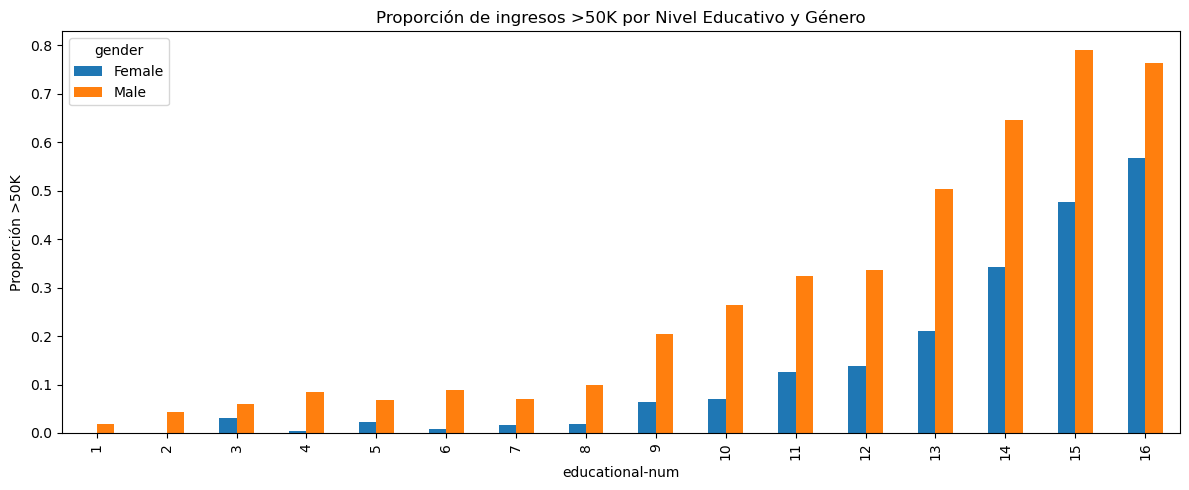

In [62]:
#Género y Educación
pivot = df_raw.pivot_table(values='income', index='educational-num', columns='gender',
                              aggfunc=lambda x: (x == '>50K').mean())
pivot.plot(kind='bar', figsize=(12, 5))
plt.title('Proporción de ingresos >50K por Nivel Educativo y Género')
plt.ylabel('Proporción >50K')
plt.tight_layout()
plt.show()

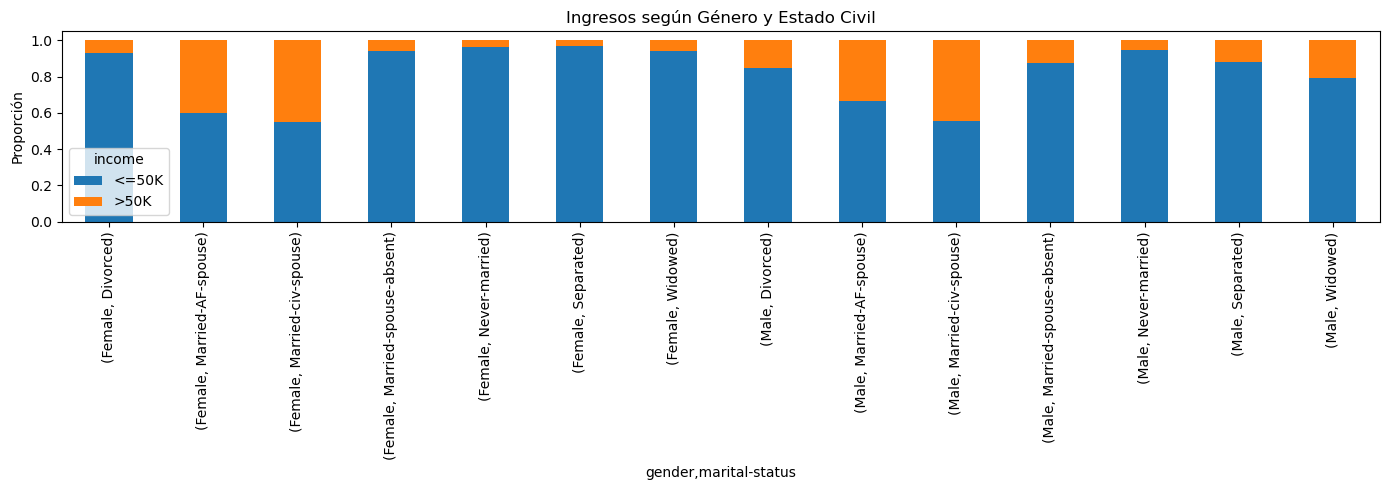

gender  marital-status       
Female  Divorced                 0.068517
        Married-AF-spouse        0.400000
        Married-civ-spouse       0.447984
        Married-spouse-absent    0.059211
        Never-married            0.035952
        Separated                0.030075
        Widowed                  0.055961
Male    Divorced                 0.150893
        Married-AF-spouse        0.333333
        Married-civ-spouse       0.445892
        Married-spouse-absent    0.123839
        Never-married            0.053390
        Separated                0.118531
        Widowed                  0.207018
Name: income, dtype: float64

In [63]:
#Estado Civil y Género
pd.crosstab([df_raw['gender'], df_raw['marital-status']], df_raw['income'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(14, 5))
plt.title('Ingresos según Género y Estado Civil')
plt.ylabel('Proporción')
plt.tight_layout()
plt.show()

df_raw.groupby(['gender', 'marital-status'])['income'].apply(lambda x: (x == '>50K').mean())


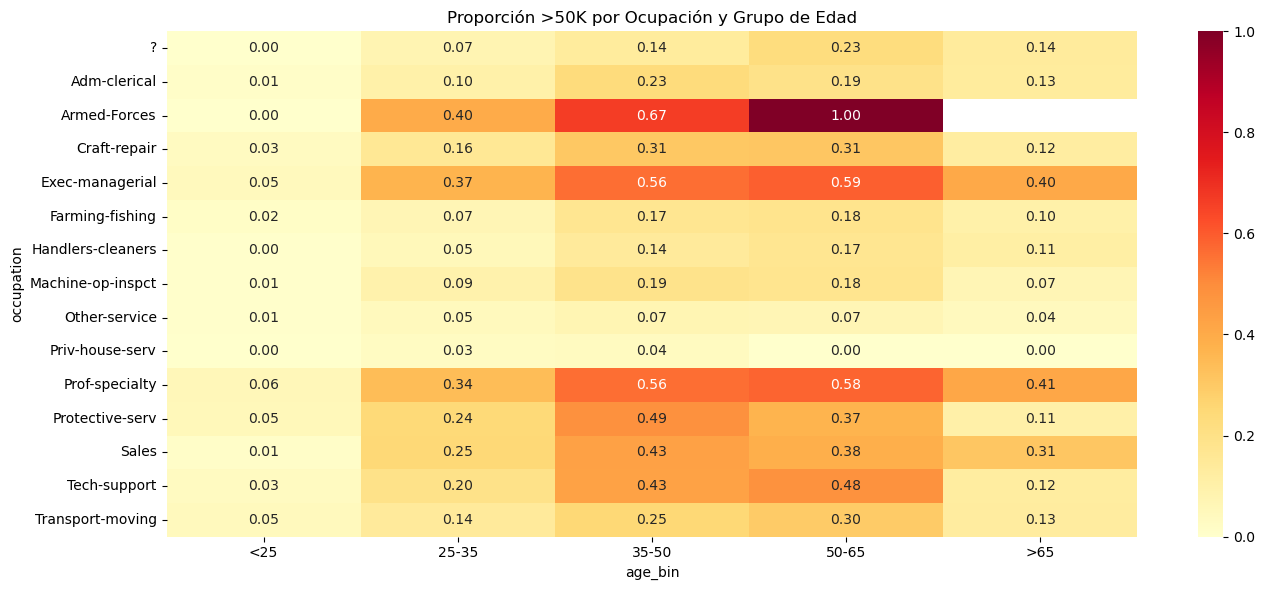

In [64]:
#Edad y Ocupación (heatmap)
plt.figure(figsize=(14, 6))
occ_age_pivot = df_raw.pivot_table(values='income', index='occupation', columns='age_bin',
                                      aggfunc=lambda x: (x == '>50K').mean())
sns.heatmap(occ_age_pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Proporción >50K por Ocupación y Grupo de Edad')
plt.tight_layout()
plt.show()

**Respuesta:** La hipótesis de interacciones analiza la combinación de tres pares de variables sobre los ingresos. Por un lado, el cruce entre género y educación revela que, aunque la brecha salarial entre hombres y mujeres se reduce a medida que aumenta el nivel educativo, esta diferencia no llega a desaparecer en ningún nivel, ni siquiera en los estudios universitarios o de posgrado. Por otro lado, el análisis de la interacción entre estado civil y género confirma que los hombres casados (Married-civ-spouse) son, con diferencia, el grupo con mayor proporción de ingresos superiores a 50K, muy por encima de cualquier otra combinación de género y estado civil. Por último, el cruce entre edad y ocupación muestra que las personas de entre 35 y 65 años empleadas en ocupaciones ejecutivas (Exec-managerial) y especializadas (Prof-specialty) concentran las tasas más altas de ingresos >50K, confirmando que la experiencia acumulada en puestos de alta responsabilidad es el factor más determinante para alcanzar ingresos elevados.


## Conclusiones:
- 